# Анализ лояльности пользователей Яндекс Афиши

### Цели и задачи проекта

<font color='#777778'>**Цель:** Провести исследовательский анализ данных лояльности пользователей сервиса "Яндекс Афиша", чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Описать профиль пользователя
4. Исследовать признаки, влияющие на совершение повторного заказа пользователями.
5. Сформулировать общий вывод и рекомендации

</font>

## Содержимое проекта
#### Оглавление

1. <a href="#section1">Загрузка данных</a>
2. <a href="#section2">Предобработка данных</a>
3. <a href="#section3">Создание профиля пользователя</a>
4. <a href="#section4">Исследовательский анализ данных</a>
    
    4.1 <a href="#section41">Исследование признаков первого заказа и их связи с возвращением на платформу</a>
    
    4.2 <a href="#section42">Исследование поведения пользователей через показатели выручки и состава заказа</a>
    
    4.3 <a href="#section43">Исследование временных характеристик первого заказа и их влияния на повторные покупки</a>
    
    4.4 <a href="#section44">Корреляционный анализ количества покупок и признаков пользователя</a>

5. <a href="#section5">Выводы и рекомендации</a>
---

<a id="section1"></a>

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка
---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. 

<u>Параметры для подключения к базе данных заданы в connection.env</u>

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Импортируем необходимые библиотеки
import pandas as pd

from sqlalchemy import create_engine

from dotenv import load_dotenv

import os

import matplotlib.pyplot as plt

import numpy as np

import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

In [2]:
# Загрузка переменных из connetion.env
load_dotenv(dotenv_path='connection.env')

host = os.getenv('HOST')
database = os.getenv('DATABASE')
port = os.getenv('PORT')
auth = os.getenv('AUTH')
user = os.getenv('USER')
password = os.getenv('PASSWORD')

In [3]:
# Создаем config для подключения
db_config = {'user': user, 
             'pwd': password, 
             'host': host,
             'port': port, 
             'db': database
             }

# Формируем строку к подключению
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

# Создаем подключение
engine = create_engine(connection_string)

In [4]:
# Формируем запрос к данным
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)

select 
  user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
	cast(p.created_dt_msk as date)- cast(LAG(p.created_dt_msk ) over (partition by p.user_id  order by p.created_dt_msk) as date) as days_since_prev,
  p.event_id,
  p.service_name,
  e.event_type_main,
  r.region_name,
  c.city_name
from afisha.purchases p
left join afisha.events as e ON p.event_id=e.event_id
left join afisha.city as c ON e.city_id=c.city_id
left join afisha.regions as r ON c.region_id=r.region_id
where 
  (p.device_type_canonical = 'mobile' 
  OR p.device_type_canonical = 'desktop')
  AND e.event_type_main != 'фильм'
order BY p.user_id
'''

In [5]:
# Создаем датафрейм для работы
df = pd.read_sql_query(query, con=engine)

In [6]:
df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,Облачко,концерты,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,Край билетов,театр,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,Лучшие билеты,театр,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,Лучшие билеты,театр,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,Лови билет!,концерты,Широковская область,Радужнополье


In [7]:
# Cоздаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len_original_df = len(temp)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [8]:
# Разработаем класс по просмотру датафрейма и разыне методы для анализа
class DataFrameReporter:
    
    def __init__(self, dataframe):
        self.df = dataframe
    
    def show_total_report(self, title=None):
        if title:
            print(title)
        
        self.df.info()

        print('Количество столбцов:', self.df.shape[1])
        print('Количество строк:', self.df.shape[0])

        duplicates = self.df.duplicated().sum()
        print('Количество дубликатов:', duplicates)

        # Защита от деления на ноль
        if self.df.shape[0] > 0:
            print('Доля дубликатов:', duplicates / self.df.shape[0])
        else:
            print('Доля дубликатов: нет строк')

        print('Количество пропусков:', self.df.isna().sum().sum())
        
        print(f'Доля пропусков: {round(self.df.isna().sum().sum() / len(self.df)*100, 2)}')
    
    def show_unique(self, column):
        unique_vals = self.df[column].sort_values().unique().tolist()
        print(f'Уникальные записи для поля {column}:\n{unique_vals}')

    
    def show_describe(self, column=None):
        if column is not None:
            if column not in self.df.columns:
                raise KeyError(f"Столбец '{column}' не найден")
            print(self.df[column].describe())
        else:
            print(self.df.describe())
    
    def show_histogram(self, column, bins=10, title=None, xlabel=None, lg=False):
        plt.figure(figsize=(12,8))
        plt.hist(self.df[column], bins=bins, alpha=1, color='salmon', edgecolor='black')
        plt.title(title) 
        plt.xlabel(xlabel)
        plt.ylabel('Частота')
        plt.grid(True)
        if lg: plt.yscale('log')
        plt.show()

    def show_boxplot(self, column, title=None, xlabel=None):
        plt.figure(figsize=(12,8))
        plt.boxplot(self.df[column], vert=False, flierprops=dict(markerfacecolor='red', marker='o'))
        plt.title(title)
        plt.xlabel(xlabel)
        plt.grid(True)
        plt.show()

    def show_diagramm(self, Xcolumn, YColumn, kind='barh', rot=0, legend=False, title=None, xlabel=None, ylabel=None):
        if kind == 'barh':
            plt.barh(self.df[YColumn], self.df[Xcolumn],
                    color='xkcd:sky blue', edgecolor='black')
        else:
            self.df.plot(x=Xcolumn, y=YColumn, kind=kind, rot=rot, legend=legend, 
                        color='xkcd:sky blue', edgecolor='black')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid()
        plt.show()   

In [9]:
# Создаем экземпрляр класса
df_reporter = DataFrameReporter(df)

# Посмотрим на общий отчет
df_reporter.show_total_report(title='Исходный датафрейм')


Исходный датафрейм
<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  region_name            290611 non-nu

In [10]:
# Первичный анализ данных
count_first_order = df['days_since_prev'].isna().sum()
print(f"""
Количество уникальных пользователей: {df['user_id'].nunique()}
Количество первых заказов: {count_first_order}
Количество уникальных заказов: {df['order_id'].nunique()}
Доля первых заказов составляет: {round(count_first_order/len(df)*100,2)}
Количество заказов с выручкой равно 0 составляет: {len(df[df['revenue'] == 0])} или {round(len(df[df['revenue'] == 0])/len(df)*100,2)}%
Количество заказов с выручкой ниже 0 составляет: {len(df[df['revenue'] < 0])} или {round(len(df[df['revenue'] < 0])/len(df)*100,2)}%
""")


Количество уникальных пользователей: 21933
Количество первых заказов: 21933
Количество уникальных заказов: 290611
Доля первых заказов составляет: 7.55
Количество заказов с выручкой равно 0 составляет: 5526 или 1.9%
Количество заказов с выручкой ниже 0 составляет: 381 или 0.13%



In [11]:
df_reporter.show_unique('device_type_canonical')
df_reporter.show_unique('event_type_main')
df_reporter.show_unique('currency_code')

Уникальные записи для поля device_type_canonical:
['desktop', 'mobile']
Уникальные записи для поля event_type_main:
['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']
Уникальные записи для поля currency_code:
['kzt', 'rub']


##### Промежуточный вывод

* Всего в датафрейме содержится 290611 строк, пропуски встречаются только в столбце `days_since_prev`, который был добавлен на этапе формирования данных (SQL запроса). Значение NULL в данном столбце означает, что это первый заказ покупателя.
* Количество заказов равно количеству строк датафрейма. Таким образом, `orer_id` уникально для каждой строки датафрейма и является первичным ключом.
* Количество первых заказов равно количеству уникальных пользователей. 
* Доля первых заказов составляет 7,55% от общего количества заказов. Таким образом, более 90% строк датафрейма это повторные заказы.
* Столбец `device_type_canonical` имеет тип str. Однако в датафрейме встречается всего 2 значения: 'desktop' и 'mobile'. Можно преобразовать к категориальному типу.
* Столбец `order_id` имеет тип int64, хотя максимальное значение составляет 8'653'108 - можно понизить до uint32, так как нет отрицательных значений.
* Столбец `order_dt` имеет тип datetime64, при этом анализ показывает, что в данном столбце время не указана, только дата. Таким образом, можно привести к типу date.
* В столбце `currency_code` содержится только 2 кода валюты: рубль и казахстанский тенге. Таким образом, необходимо учмитывать код валюты при анализе столбца `revenue`
* Столбец `revenue` имеет тип float64 - можно понизить до float32
* В столбце `revenue` содержатся значения равные 0 (~1,9% от всех данных) и отрицательные значения (~0,13%). Учитывая, что данный столбец отражает выручку от продажи билетов, то можно предположить, что заказы с нулевой выручкой это билеты на бесплатное мероприятие или билеты, например, по промокоду или по какой-то акции. Заказы с отрицательной выручкой могут говорить о том, что это возврат ранее купленных билетов, то есть для возврата оформляется отдельный заказ. Но это так же может быть и технической ошибкой. Для корректного вывода необходимо провести дополнительный анализ.
* Столбец `tickets_count` имеет тип int64. При этом в данном поле значения  содержаться от 1 до 57, отрицательные значения отсутствуют. Можно преобразовать к типу uint8 (беззнаковое 8-битное целое).
* Столбец `days_since_prev` имеет тип float64, однако значения встречаются в диапазоне от 0 до 148. Поскольку в данном столбце встречаются значения NULL, то можно преобразовать к типу UInt8 (nullable-тип pandas).
* Столбец `event_id` имеет тип int64 можно преобразовать к uint32, отрицательных значений нет.
* Столбец `event_type_main` содержит значения: 'выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки'. Можно преобразовать к категориальному типу данных, вместо str
* Столбцы `service_name`, `region_name` и `city_name` могут содержать неявные дубликаты - необходимо проверить на этапе предобработки данных.

Таким образом, данные датафрейма корректны.

<a id="section2"></a>
---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [12]:
# Получим данные о курсе рубля и тенге
df_curr_rates = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

df_curr_rates_reporter = DataFrameReporter(df_curr_rates)
df_curr_rates_reporter.show_total_report(title='Датафрейм о курсах валют')

Датафрейм о курсах валют
<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB
Количество столбцов: 4
Количество строк: 357
Количество дубликатов: 0
Доля дубликатов: 0.0
Количество пропусков: 0
Доля пропусков: 0.0


In [13]:
df_curr_rates.head(10)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
5,2024-01-15,100,19.4501,kzt
6,2024-01-16,100,19.4264,kzt
7,2024-01-17,100,19.4177,kzt
8,2024-01-18,100,19.5798,kzt
9,2024-01-19,100,19.5741,kzt


In [14]:
# Преобразуем столбец `data` из str в date
df_curr_rates['data'] = pd.to_datetime(df_curr_rates['data'])

In [15]:
#Проверим уникальность поля `data`
df_curr_rates['data'].nunique()

357

In [16]:
#Отберем в исходном датафрейме все строки у которых валюта kzt
df_kzt = df[df['currency_code']=='kzt']

df_kzt_reporter = DataFrameReporter(df_kzt)
df_kzt_reporter.show_total_report(title='Датафрейм с заказами в тенге')

Датафрейм с заказами в тенге
<class 'pandas.DataFrame'>
Index: 5069 entries, 70 to 290489
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                5069 non-null   str           
 1   device_type_canonical  5069 non-null   str           
 2   order_id               5069 non-null   int64         
 3   order_dt               5069 non-null   datetime64[us]
 4   order_ts               5069 non-null   datetime64[us]
 5   currency_code          5069 non-null   str           
 6   revenue                5069 non-null   float64       
 7   tickets_count          5069 non-null   int64         
 8   days_since_prev        4195 non-null   float64       
 9   event_id               5069 non-null   int64         
 10  service_name           5069 non-null   str           
 11  event_type_main        5069 non-null   str           
 12  region_name            5069 non-null   str    

Получили 5069 записей

In [17]:
# Объединеним датафрейм с заказами в тенге и курсами валюты, переведем тенге в рубли
df_merge_kzt = df_kzt.merge(df_curr_rates, left_on='order_dt', right_on='data', how='left')
df_merge_kzt['revenue_rub'] = round(df_merge_kzt['revenue'] * df_merge_kzt['curs'] / 100, 2)

df_merge_kzt_reporter = DataFrameReporter(df_merge_kzt)
df_merge_kzt_reporter.show_total_report(title='Датафрейм о курсах валют')

Датафрейм о курсах валют
<class 'pandas.DataFrame'>
RangeIndex: 5069 entries, 0 to 5068
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                5069 non-null   str           
 1   device_type_canonical  5069 non-null   str           
 2   order_id               5069 non-null   int64         
 3   order_dt               5069 non-null   datetime64[us]
 4   order_ts               5069 non-null   datetime64[us]
 5   currency_code          5069 non-null   str           
 6   revenue                5069 non-null   float64       
 7   tickets_count          5069 non-null   int64         
 8   days_since_prev        4195 non-null   float64       
 9   event_id               5069 non-null   int64         
 10  service_name           5069 non-null   str           
 11  event_type_main        5069 non-null   str           
 12  region_name            5069 non-null   str      

Все строки обработались, значит курсы тенге были для каждой даты, которая встречается в таблице с заказами

In [18]:
#Добавим в исходный датафрейм новое поле 'revenue_rub'
df = df.merge(df_merge_kzt[['order_id', 'revenue_rub']], on='order_id', how='left')

#Пропущенные значения нового поля (те заказы, где валюта рубли) заполним значением из поля поля 'revenue'.
df['revenue_rub']=df['revenue_rub'].fillna(df['revenue'])

df_reporter = DataFrameReporter(df)
df_reporter.show_total_report()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  region_name            290611 non-null  str           


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [19]:
# Приведем столбцы к нужному типу данных.
df[['device_type_canonical', 'event_type_main']] = df[['device_type_canonical', 'event_type_main']].astype('category')
df[['order_id', 'event_id']] = df[['order_id', 'event_id']].astype('uint32')
df[['revenue', 'revenue_rub']] = df[['revenue', 'revenue_rub']].astype('float32')
df['tickets_count'] = df['tickets_count'].astype('uint8')
df['days_since_prev'] = df['days_since_prev'].astype('UInt8')
df['order_dt'] = df['order_dt'].dt.date

In [20]:
df_reporter.show_total_report()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  uint32        
 3   order_dt               290611 non-null  object        
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  uint8         
 8   days_since_prev        268678 non-null  UInt8         
 9   event_id               290611 non-null  uint32        
 10  service_name           290611 non-null  str           
 11  event_type_main        290611 non-null  category      
 12  region_name            290611 non-null  str           


Задание: Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.

In [21]:
df_reporter.show_unique('device_type_canonical')
df_reporter.show_unique('event_type_main')

Уникальные записи для поля device_type_canonical:
['desktop', 'mobile']
Уникальные записи для поля event_type_main:
['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']


Данные корректны, дополнительная обработка не требуется.

In [22]:
# Приведем столбцы с текстом к нижнему регистру
cols = ['service_name', 'region_name', 'city_name']
for col in cols:
    df[col] = df[col].str.lower()

Задание: 
Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха. 
Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах. 
Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

In [23]:
# Проанализируем статистические показатели поля `reveue_rub`
df_reporter.show_describe('revenue_rub')

count    290611.000000
mean        555.571960
std         875.498169
min         -90.760002
25%         113.970001
50%         351.140015
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64


Анализ показывает, что среднее значние сильно отличается от медианы (50 перцентиль), а также довольно высокое стандартное отклонение, что говорит о наличии в данных выбросов. Также, как было отмечено ранее, в данных встречается отрицательное значение и значение равное 0, что может говорить о том, что это могут быть возвраты билетов либо продажи билетов, например, по промокоду, то есть выручка по ним равна 0.

In [24]:
# Проанализируем статистические показатели поля `reveue_rub`
df_reporter.show_describe('tickets_count')

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


Анализ показывает, что по столбцу есть выбросы, так как 75 перценитиль это 4 купленых билета, а максимальное значение составляет 57 билетов. 

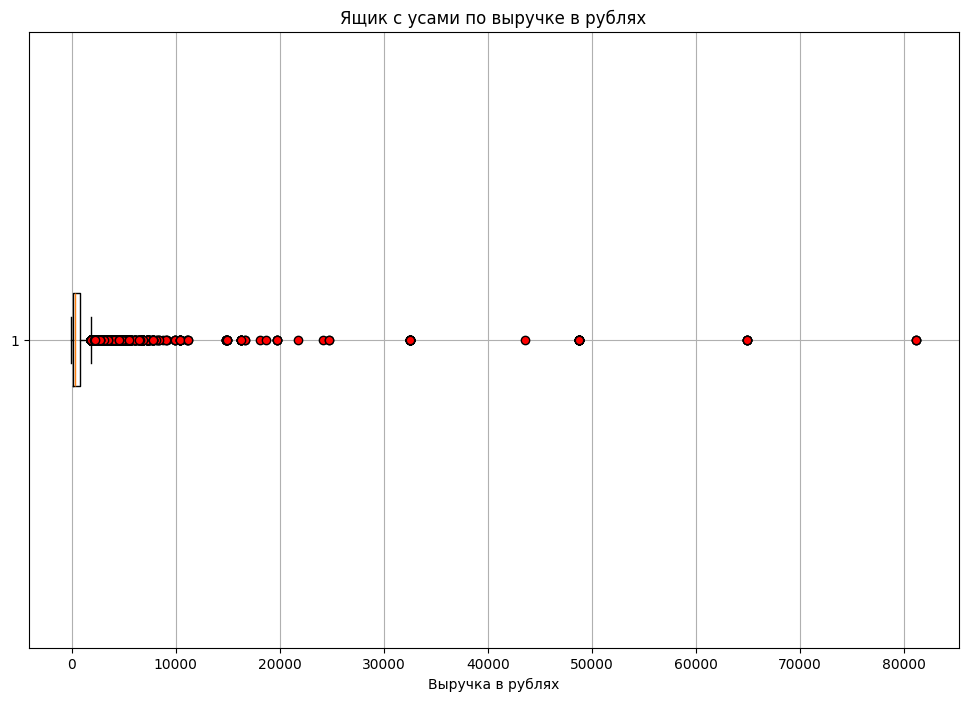

In [25]:
# Построим "ящик с усами" по 'revenue_rub'
df_reporter.show_boxplot('revenue_rub', 'Ящик с усами по выручке в рублях', 'Выручка в рублях')

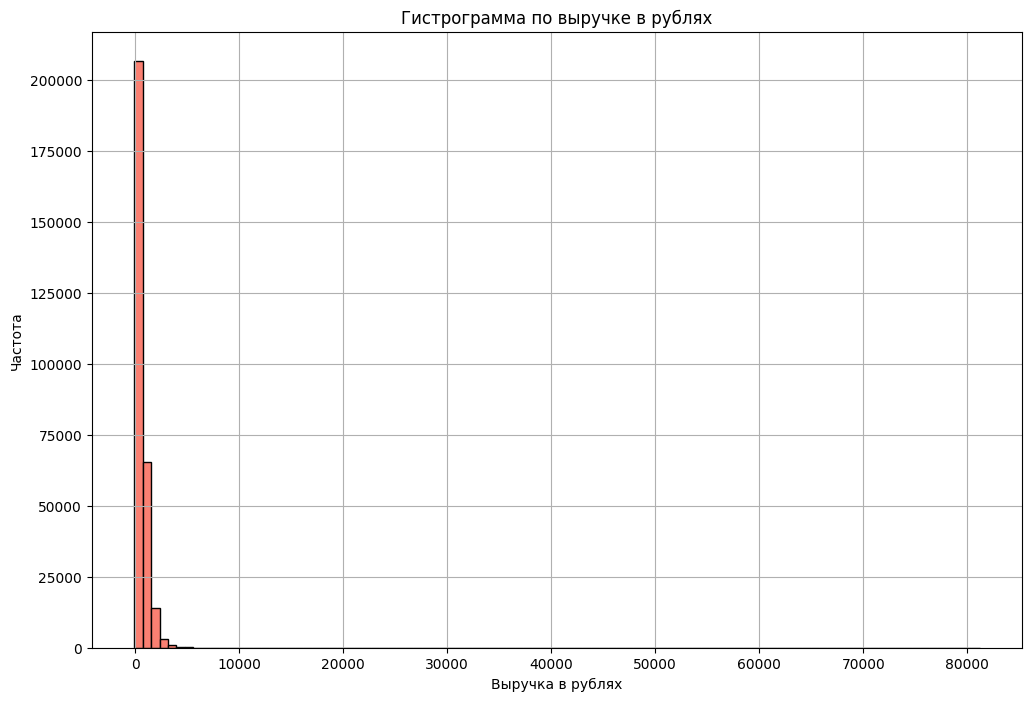

In [26]:
# Построим гистрограмму по 'revenue_rub'
df_reporter.show_histogram('revenue_rub',
                           100,
                           'Гистрограмма по выручке в рублях',
                           'Выручка в рублях')

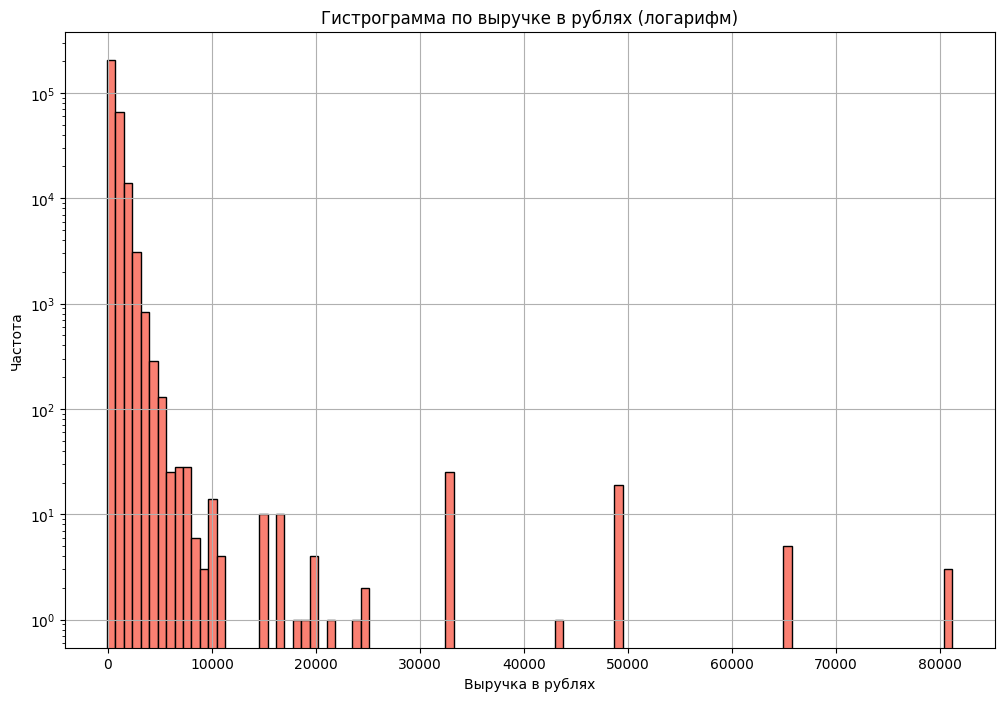

In [27]:
# Построим гистрограмму по 'revenue_rub'используя логарифмическую шкалу для нагладности
df_reporter.show_histogram('revenue_rub',
                           100,
                           'Гистрограмма по выручке в рублях (логарифм)',
                           'Выручка в рублях',
                           True)


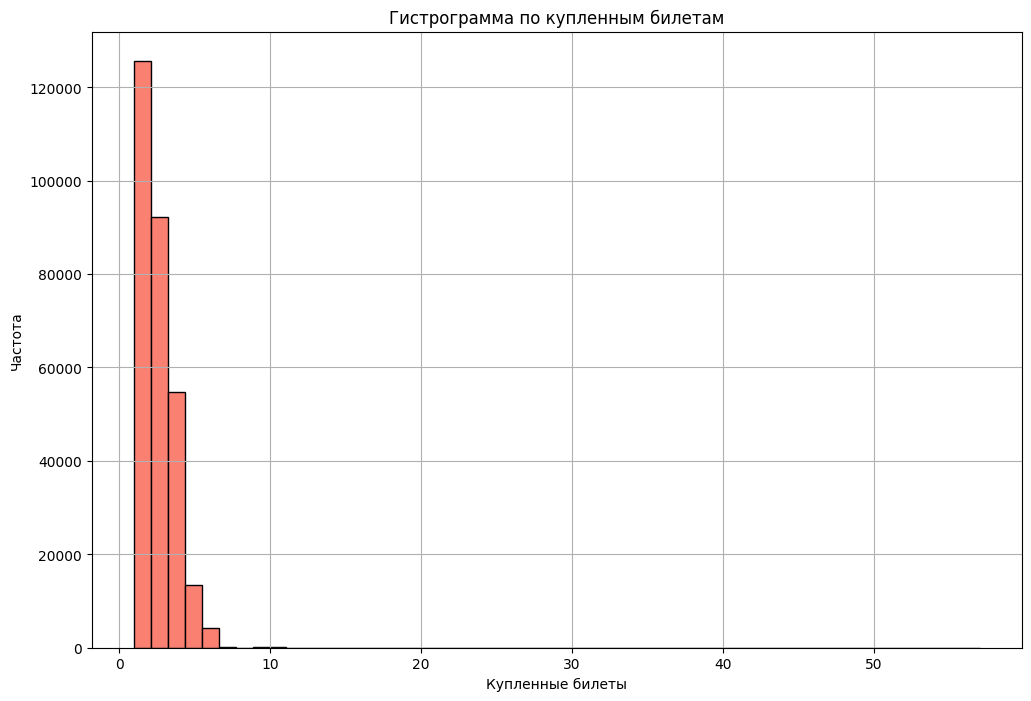

In [28]:
# Построим гистрограмму по 'tickets_count'
df_reporter.show_histogram('tickets_count',
                           50,
                           'Гистрограмма по купленным билетам',
                           'Купленные билеты')

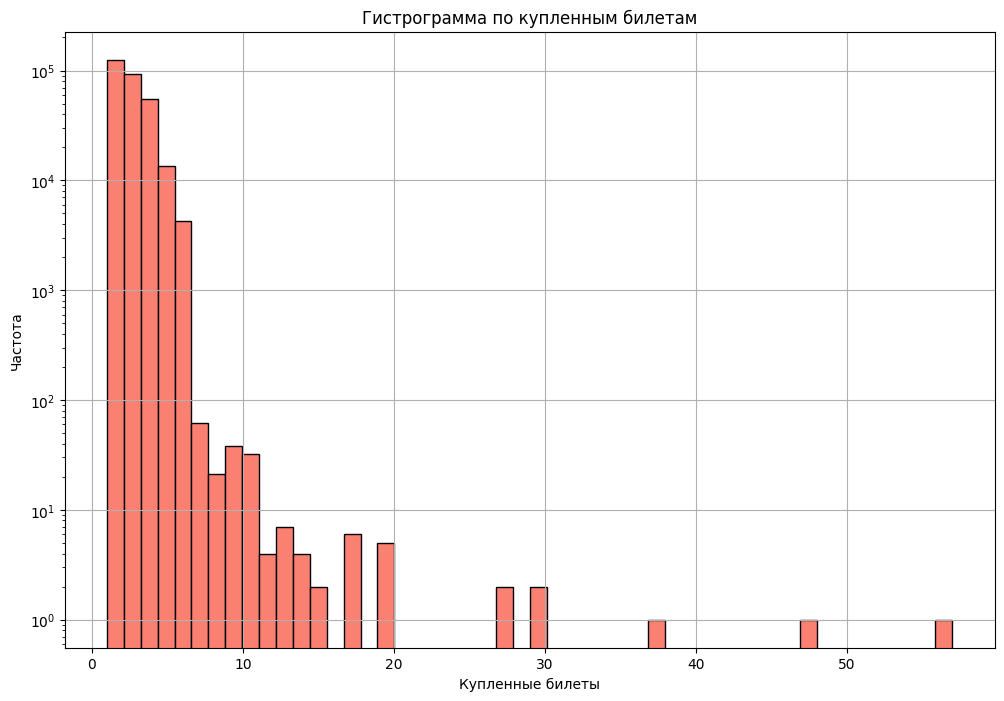

In [29]:
# Построим гистрограмму по 'tickets_count' используя логарифмическую шкалу для нагладности
df_reporter.show_histogram('tickets_count',
                           50,
                           'Гистрограмма по купленным билетам',
                           'Купленные билеты',
                           True)

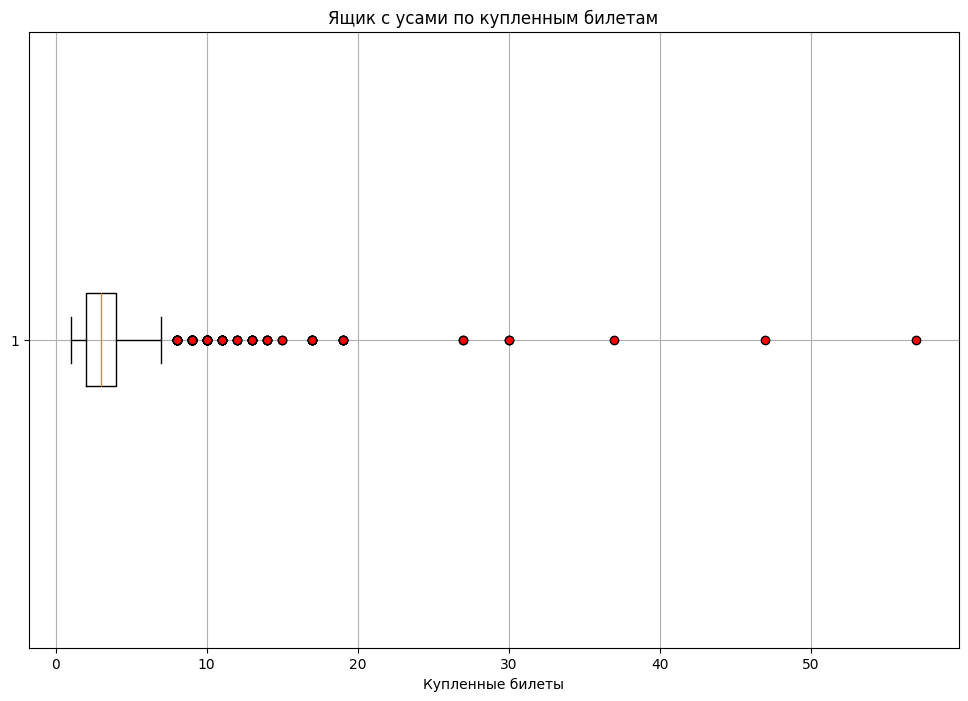

In [30]:
# Построим "ящик с усами" по 'tickets_count'
df_reporter.show_boxplot('tickets_count', 'Ящик с усами по купленным билетам', 'Купленные билеты')

Как видно из приведенных графиков, в подтверждение статистического анализа, по столбцу `revenue_rub` присутствуют выбросы данных.
Отфильтруем датафрейм по 99 перцентилю, посмотрим общую инфорамацию после фильтрации, графики и посчитаем процент оставшихся данных после фильтрации 

<class 'pandas.DataFrame'>
Index: 285178 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                285178 non-null  str           
 1   device_type_canonical  285178 non-null  category      
 2   order_id               285178 non-null  uint32        
 3   order_dt               285178 non-null  object        
 4   order_ts               285178 non-null  datetime64[us]
 5   currency_code          285178 non-null  str           
 6   revenue                285178 non-null  float32       
 7   tickets_count          285178 non-null  uint8         
 8   days_since_prev        263918 non-null  UInt8         
 9   event_id               285178 non-null  uint32        
 10  service_name           285178 non-null  str           
 11  event_type_main        285178 non-null  category      
 12  region_name            285178 non-null  str           
 13  

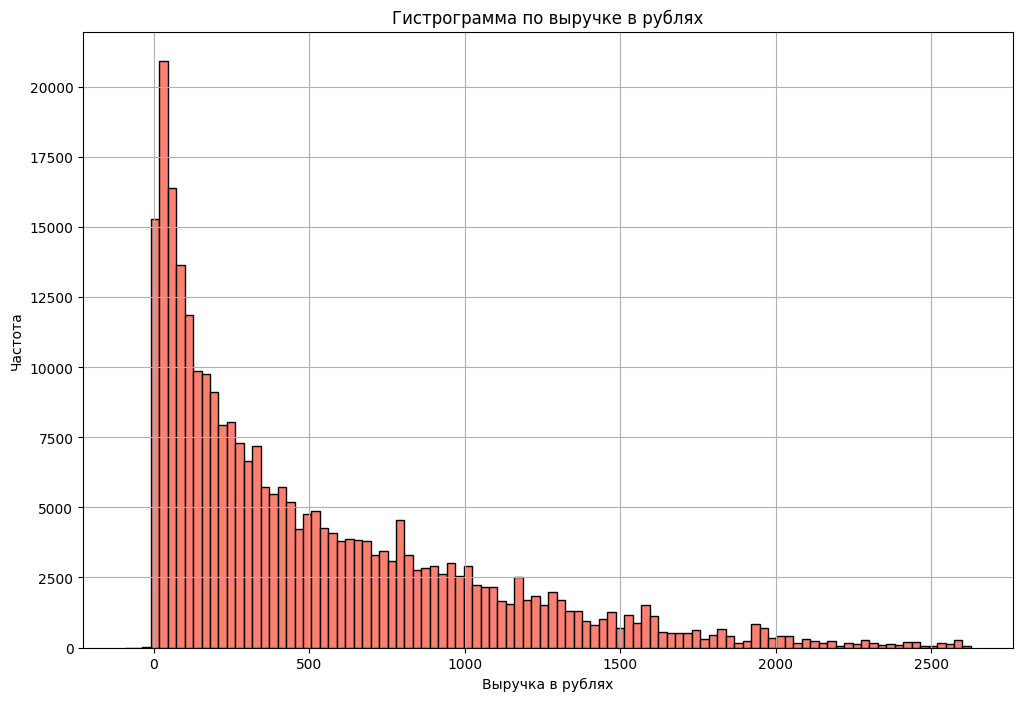

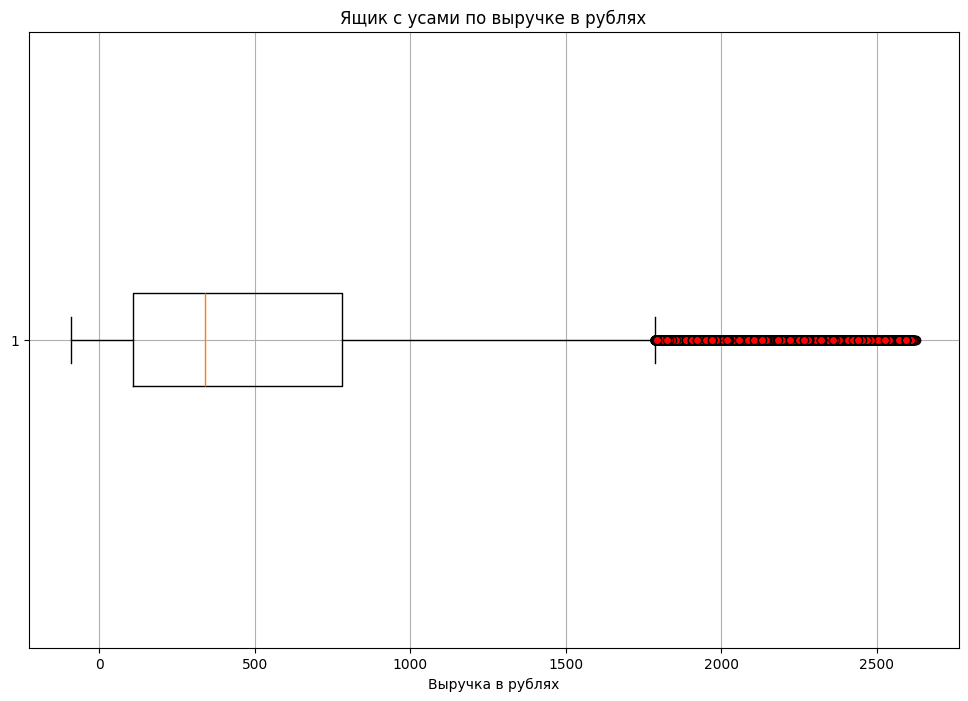

290611 285178 5433 1.87


In [31]:
revenue_rub_99 = df['revenue_rub'].quantile(0.99)
df_revenue_99 = df[df['revenue'] <= revenue_rub_99]

#Перепределим рабочий датафрейм
df = df_revenue_99
df_reporter = DataFrameReporter(df)
df_reporter.show_total_report()
df_reporter.show_histogram('revenue_rub',
                           100,
                           'Гистрограмма по выручке в рублях',
                           'Выручка в рублях')
df_reporter.show_boxplot('revenue_rub', 'Ящик с усами по выручке в рублях', 'Выручка в рублях')

# Проверим сколько осталось строк датафрейма после фильтрации
a, b = len(temp), len(df)
print(a, b, a-b, round((a-b)/a*100, 2))

В результате предобработки данных в итоговый датафрейм было добавлено новое поле "revenue_rub", которое показывает выручку от продажи билетов в рублях. Для этого по тем закакам, которые были оформлены в тенге был сделан пересчет по курсу из специального датасета с курсами тенге на каждую дату из расчета 100 тенге. 
Также был проведен анализ и произведена работа по типизации данных в датафрейме, что позволило уменьшить разрядность по суммовым некоторым полям.
Итоговый датафрейм был отфильтрован по 99 перцентилю по полю "revenue_rub", так как в данном столбце наблюдались значительные выбросы данных. В результате такой фильтрации итоговый датафрейм был уменьшен на 5433 записей, что составило 1,87% от исходного датафрейма.

---
<a id="section3"></a>
### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [32]:
# Сортируем датафрейм по времени совершения заказа
df = df.sort_values(["user_id","order_ts"])

In [33]:
# Посчитаем общие показатели по пользователю
user_aggr_data = (df.groupby('user_id')
    .agg(first_order_dt=('order_dt', 'min'),
         last_order_dt=('order_dt', 'max'),
         qty_orders=('order_id', 'count'),
         avg_revenue_rub=('revenue_rub', 'mean'),
         avg_tickets=('tickets_count', 'mean'),
         avg_order_days=('days_since_prev', 'mean'))
    .reset_index()
)
len(user_aggr_data)

21642

In [34]:
# Посчитаем показатели пользователя по первому заказу
min_dates = df.groupby('user_id')['order_ts'].min().reset_index()
first_orders = df.merge(min_dates, on=['user_id', 'order_ts'])


user_first_order_aggr_data = first_orders[['user_id', 
                                           'device_type_canonical',
                                           'region_name',
                                           'service_name',
                                           'event_type_main']].rename(
        columns={'device_type_canonical': 'first_device_type',
                 'region_name' : 'first_region',
                 'service_name' : 'firts_service_name',
                 'event_type_main' : 'first_event_type'})

len(user_first_order_aggr_data)


21642

In [35]:
# Соберем данные в единый профиль пользователя
user_profile = pd.merge(user_first_order_aggr_data, user_aggr_data, on='user_id')

user_profile['is_two'] = user_profile['qty_orders'] >= 2
user_profile['is_five'] = user_profile['qty_orders'] >= 5

user_profile_reporter = DataFrameReporter(user_profile)
user_profile_reporter.show_total_report()

user_profile.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 21642 entries, 0 to 21641
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   user_id             21642 non-null  str     
 1   first_device_type   21642 non-null  category
 2   first_region        21642 non-null  str     
 3   firts_service_name  21642 non-null  str     
 4   first_event_type    21642 non-null  category
 5   first_order_dt      21642 non-null  object  
 6   last_order_dt       21642 non-null  object  
 7   qty_orders          21642 non-null  int64   
 8   avg_revenue_rub     21642 non-null  float32 
 9   avg_tickets         21642 non-null  float64 
 10  avg_order_days      13425 non-null  Float64 
 11  is_two              21642 non-null  bool    
 12  is_five             21642 non-null  bool    
dtypes: Float64(1), bool(2), category(2), float32(1), float64(1), int64(1), object(2), str(3)
memory usage: 1.5+ MB
Количество столбцов: 13
Количество с

,user_id,first_device_type,first_region,firts_service_name,first_event_type,first_order_dt,last_order_dt,qty_orders,avg_revenue_rub,avg_tickets,avg_order_days,is_two,is_five
0,0002849b70a3ce2,mobile,каменевский регион,край билетов,театр,2024-08-20,2024-08-20,1,1521.939941,4.000000,<NA>,False,False
1,0005ca5e93f2cf4,mobile,каменевский регион,мой билет,выставки,2024-07-23,2024-10-06,2,774.010010,3.000000,75.0,True,False
2,000898990054619,mobile,североярская область,лови билет!,другое,2024-07-13,2024-10-23,3,767.213379,2.666667,51.0,True,False
3,00096d1f542ab2b,desktop,каменевский регион,край билетов,театр,2024-08-15,2024-08-15,1,917.830017,4.000000,<NA>,False,False
4,000a55a418c128c,mobile,поленовский край,лучшие билеты,театр,2024-09-29,2024-10-15,2,61.309998,1.500000,16.0,True,False
5,000cf0659a9f40f,mobile,широковская область,лови билет!,концерты,2024-06-20,2024-06-21,13,1175.808472,3.307692,0.083333,True,True
6,00147c9209d45d3,mobile,каменевский регион,облачко,концерты,2024-06-25,2024-06-25,2,352.945007,1.500000,0.0,True,False
7,0018ecd8a38a51b,mobile,медовская область,билеты без проблем,спорт,2024-07-25,2024-07-25,1,0.000000,3.000000,<NA>,False,False
8,00199a573901564,mobile,каменевский регион,билеты без проблем,концерты,2024-06-17,2024-06-17,1,588.119995,4.000000,<NA>,False,False
9,001e7037d013f0f,mobile,златопольский округ,мой билет,другое,2024-07-04,2024-09-29,3,326.623322,1.333333,43.5,True,False


Пропуски тольео в столбце `mean_order_days` - это означает, что данный пользователь совершил только один заказ. Оставим как есть, так как если поставить 0, то это может сильно исказить данные

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [36]:
# Рассчитаем общее число пользователей в выборке
print(f"Общее количество пользователей: {len(user_profile)}")

Общее количество пользователей: 21642


In [37]:
#Посчитаем среднюю выручку с одного заказа
orders_count = user_profile['qty_orders'].sum()
print(f"Среднняя выручка с одного заказа: {round(user_profile['avg_revenue_rub'].sum()/orders_count, 2)}")

Среднняя выручка с одного заказа: 40.42


In [38]:
# Доля пользователей, совершивших 2 и более заказа
print(f"Доля пользователей, совершивших 2 и более заказа: {round(user_profile['is_two'].sum()/len(user_profile)*100, 2)}")

Доля пользователей, совершивших 2 и более заказа: 61.66


In [39]:
# Доля пользователей, совершивших 5 и более заказа
print(f"Доля пользователей, совершивших 5 и более заказа: {round(user_profile['is_five'].sum()/len(user_profile)*100, 2)}")

Доля пользователей, совершивших 5 и более заказа: 29.01


In [40]:
user_profile_reporter = DataFrameReporter(user_profile)
user_profile.describe()

,qty_orders,avg_revenue_rub,avg_tickets,avg_order_days
count,21642.000000,21642.000000,21642.000000,13425.0
mean,13.177063,532.645142,2.741974,16.032472
std,121.613664,425.036133,0.918229,22.506142
min,1.000000,-10.770000,1.000000,0.0
25%,1.000000,205.362503,2.000000,1.007143
50%,2.000000,454.508194,2.750000,8.125
75%,5.000000,747.675812,3.090909,20.666667
max,10138.000000,2617.479980,11.000000,148.0


Проведенный анализ показывает:
* Количество данных 21642 - достаточный объем данных для анализа
* Среднее количество заказов клиента - присутствуют экстремальные выбросы — небольшое число пользователей с аномально высоким числом заказов. При медиане = 2, среднее составляет 13,18, а стандартное отклонение (121,6) сильно превышает среднее. Значение 10 138 заказов при медиане 2 — явная аномалия.
* Среднее количество билетов одного заказа - среднее и медиана практически равны, стандартное отклоение ~ 1 билет, максимальное количество в 11 билетов не стоит рассматривать как выброс - возможно это куплено на группу человек.
* среднее количество дней между заказами - тут стоит учитывать, что это только ~62% данных, так как пропущенные значения это означает что пользователь совершил всего один заказ. 

Вывод: отберем по 99 перцентилю данные по количеству заказов и посмотрим насколько это повлияет на статистику.

In [41]:
qty_orders_99 = user_profile['qty_orders'].quantile(0.99)
user_profile_99 = user_profile[user_profile['qty_orders'] <= qty_orders_99]

# Проверим сколько осталось строк датафрейма после фильтрации
a, b = len(user_profile), len(user_profile_99)
print(a, b, a-b, round((a-b)/a*100, 2))


user_profile_99.describe()

21642 21426 216 1.0


,qty_orders,avg_revenue_rub,avg_tickets,avg_order_days
count,21426.000000,21426.000000,21426.000000,13209.0
mean,6.485158,532.898376,2.742150,16.287137
std,14.243657,427.037750,0.922703,22.60039
min,1.000000,-10.770000,1.000000,0.0
25%,1.000000,202.840832,2.000000,1.432692
50%,2.000000,451.806702,2.750000,8.5
75%,5.000000,752.270447,3.111111,21.0
max,152.000000,2617.479980,11.000000,148.0


Фильтрация по 99 перцентилю всё еще показывает выбросы, но уже не такие высокие. Данных стало меньше на 1%.
Попробуем отфильтровать по 95 перцентилю и посмотрим на статистику.

In [42]:
qty_orders_95 = user_profile['qty_orders'].quantile(0.95)
user_profile_95 = user_profile[user_profile['qty_orders'] <= qty_orders_95]

# Проверим сколько осталось строк датафрейма после фильтрации
a, b = len(user_profile), len(user_profile_95)
print(a, b, a-b, round((a-b)/a*100, 2))


user_profile_95.describe()

21642 20585 1057 4.88


,qty_orders,avg_revenue_rub,avg_tickets,avg_order_days
count,20585.000000,20585.000000,20585.000000,12368.0
mean,4.081321,534.697876,2.742383,17.223238
std,5.205680,434.137024,0.939432,23.058127
min,1.000000,-10.770000,1.000000,0.0
25%,1.000000,195.955002,2.000000,1.0
50%,2.000000,446.368317,2.750000,9.5
75%,5.000000,764.775024,3.166667,22.4
max,32.000000,2617.479980,11.000000,148.0


Данных стало меньше примерно на 5%, но при этом критические выбросы ушли. 

При 95 перцентиле по количеству заказов данные по количеству билетов и дней между заказами не сильно изменились. Оставим для дальнейшего анализа 95 перцентиль. Создадим итоговый датафрейм для дальнейшего исследовательского анализа данных. 

In [43]:
df_analisys = user_profile_95
df_analisys.to_csv('df_analisys')
#Посмотрим на общую информацию по итоговому датафрейму
df_analisys_reporter = DataFrameReporter(df_analisys)
df_analisys_reporter.show_total_report()
df_analisys_reporter.show_describe()

<class 'pandas.DataFrame'>
Index: 20585 entries, 0 to 21641
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   user_id             20585 non-null  str     
 1   first_device_type   20585 non-null  category
 2   first_region        20585 non-null  str     
 3   firts_service_name  20585 non-null  str     
 4   first_event_type    20585 non-null  category
 5   first_order_dt      20585 non-null  object  
 6   last_order_dt       20585 non-null  object  
 7   qty_orders          20585 non-null  int64   
 8   avg_revenue_rub     20585 non-null  float32 
 9   avg_tickets         20585 non-null  float64 
 10  avg_order_days      12368 non-null  Float64 
 11  is_two              20585 non-null  bool    
 12  is_five             20585 non-null  bool    
dtypes: Float64(1), bool(2), category(2), float32(1), float64(1), int64(1), object(2), str(3)
memory usage: 1.6+ MB
Количество столбцов: 13
Количество строк:

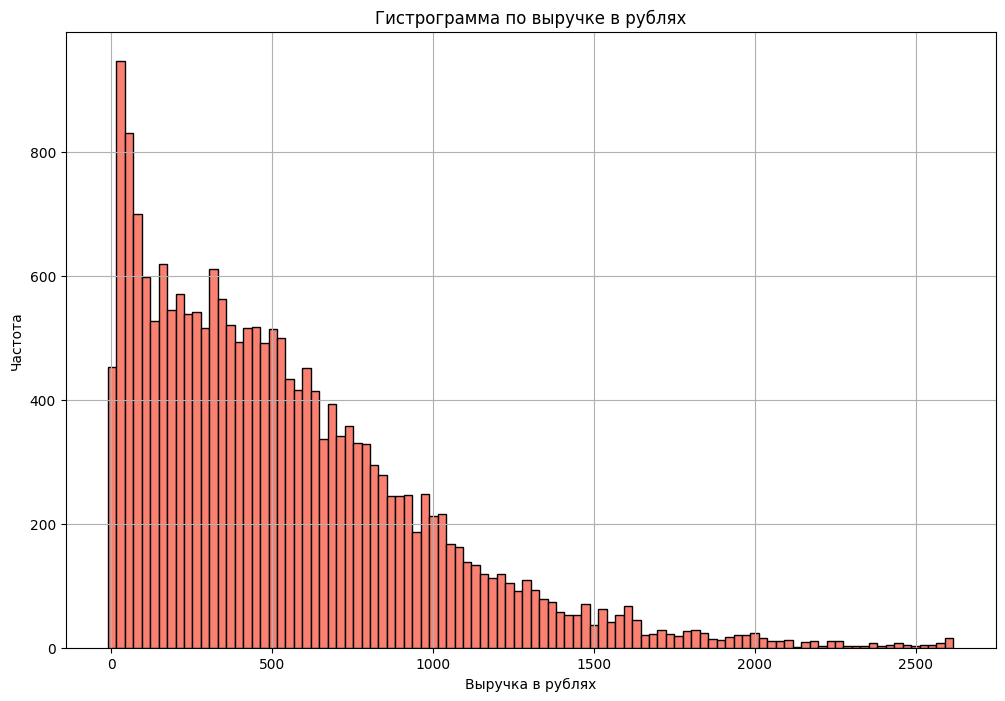

In [44]:
df_analisys_reporter.show_histogram('avg_revenue_rub',
                           100,
                           'Гистрограмма по выручке в рублях',
                           'Выручка в рублях')

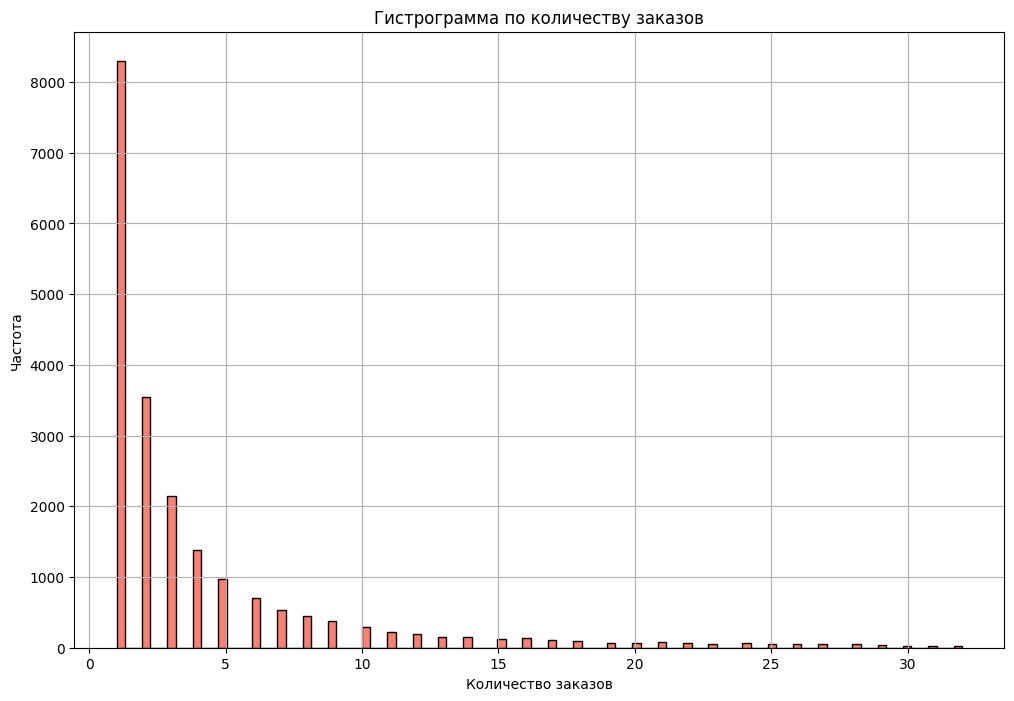

In [45]:
df_analisys_reporter.show_histogram('qty_orders',
                           100,
                           'Гистрограмма по количеству заказов',
                           'Количество заказов')

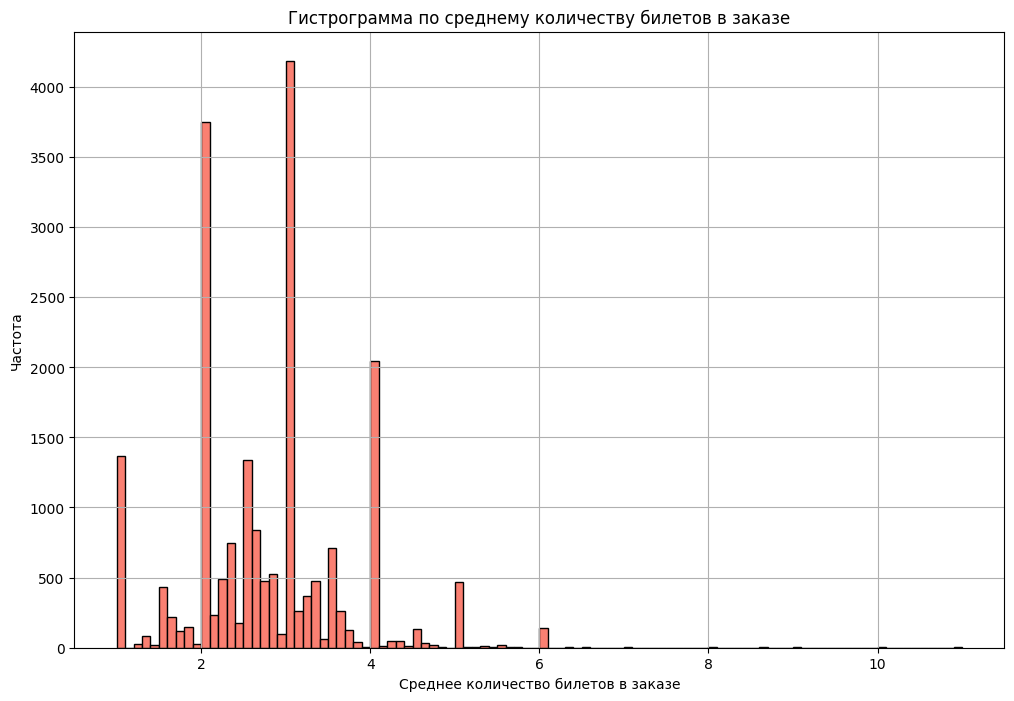

In [46]:
df_analisys_reporter.show_histogram('avg_tickets',
                           100,
                           'Гистрограмма по среднему количеству билетов в заказе',
                           'Среднее количество билетов в заказе')

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.

<a id="section4"></a>

#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу
<a id="section41"></a>
Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [47]:
# Разработаем класс UserProfile с различными методами для анализа профиля пользователя
class UserProfile:
    
    def __init__(self, dataframe):
        self.df = dataframe
    
    def create_user_segment(self, group_col, target_col, group_agg='count', total_agg='sum'):
        df_segment = self.df.groupby(group_col)[target_col].agg(group_agg).reset_index(name=target_col)
        total = df_segment[target_col].agg(total_agg)
        df_segment['ratio'] = df_segment[target_col] / total * 100
        return df_segment.sort_values('ratio', ascending=False)
  
    def show_diagramm(self, df_segment, Xcolumn, YColumn, legend=False, title=None, xlabel=None, ylabel=None, width=8, height=6):
        df_segment = df_segment.sort_values(by=Xcolumn)
        plt.figure(figsize=(width,height))
        plt.barh(df_segment[YColumn], df_segment[Xcolumn], color='xkcd:sky blue', edgecolor='black')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid()
        plt.show()

In [48]:
# Создадим экземпляр класс UserProfile
user_profile = UserProfile(df_analisys) 

  first_event_type  user_id      ratio
2         концерты     8862  43.050765
1           другое     5261  25.557445
5            театр     4106  19.946563
4          стендап     1081   5.251397
3            спорт      775   3.764877
0         выставки      406   1.972310
6             ёлки       94   0.456643


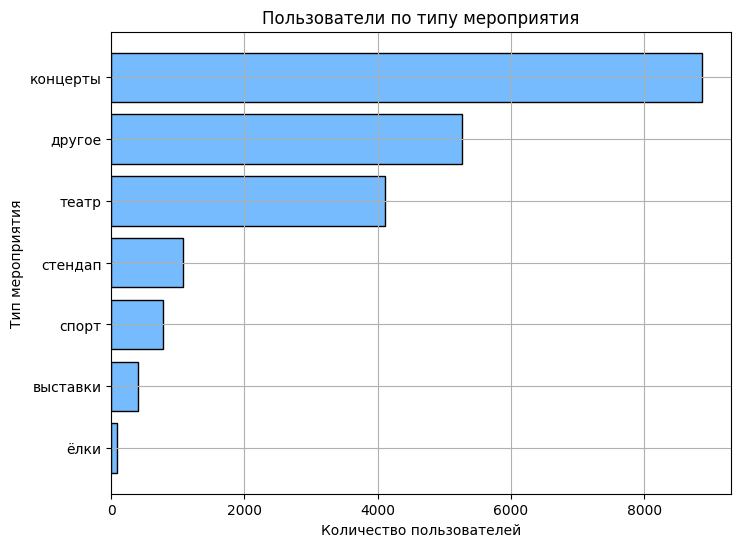

In [49]:
# Сгруппируем пользователей по типу их первого мероприятия
seg_event_type = user_profile.create_user_segment('first_event_type', 'user_id')
print(seg_event_type.head(10))

user_profile.show_diagramm(seg_event_type, title="Пользователи по типу мероприятия",
                            Xcolumn='user_id',
                            YColumn='first_event_type',
                            xlabel="Количество пользователей", 
                            ylabel="Тип мероприятия")


  first_device_type  user_id     ratio
1            mobile    17113  83.13335
0           desktop     3472  16.86665


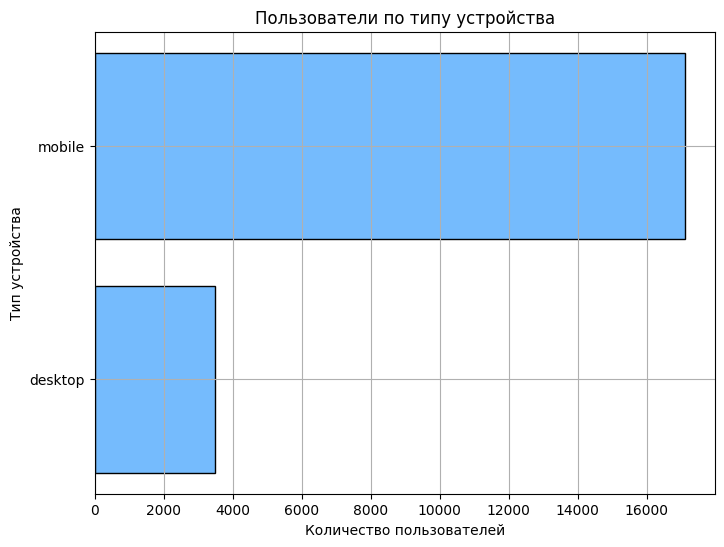

In [50]:
# Сгруппируем пользователей по типу усройства
seg_device_type = user_profile.create_user_segment('first_device_type', 'user_id')
print(seg_device_type.head(10))

user_profile.show_diagramm(seg_device_type, title="Пользователи по типу устройства",
                            Xcolumn='user_id',
                            YColumn='first_device_type',
                            xlabel="Количество пользователей", 
                            ylabel="Тип устройства")

In [51]:
# Сгруппируем пользователей по региону
seg_region = user_profile.create_user_segment('first_region', 'user_id')
print(len(seg_region))


81


            first_region  user_id      ratio
23    каменевский регион     6841  33.232937
60  североярская область     3637  17.668205
77   широковская область     1193   5.795482
45      озернинский край      666   3.235366
41  малиновоярский округ      521   2.530969
74      травяная область      469   2.278358
57  светополянский округ      443   2.152052
52   речиновская область      427   2.074326
78   яблоневская область      400   1.943162
42     медовская область      359   1.743988


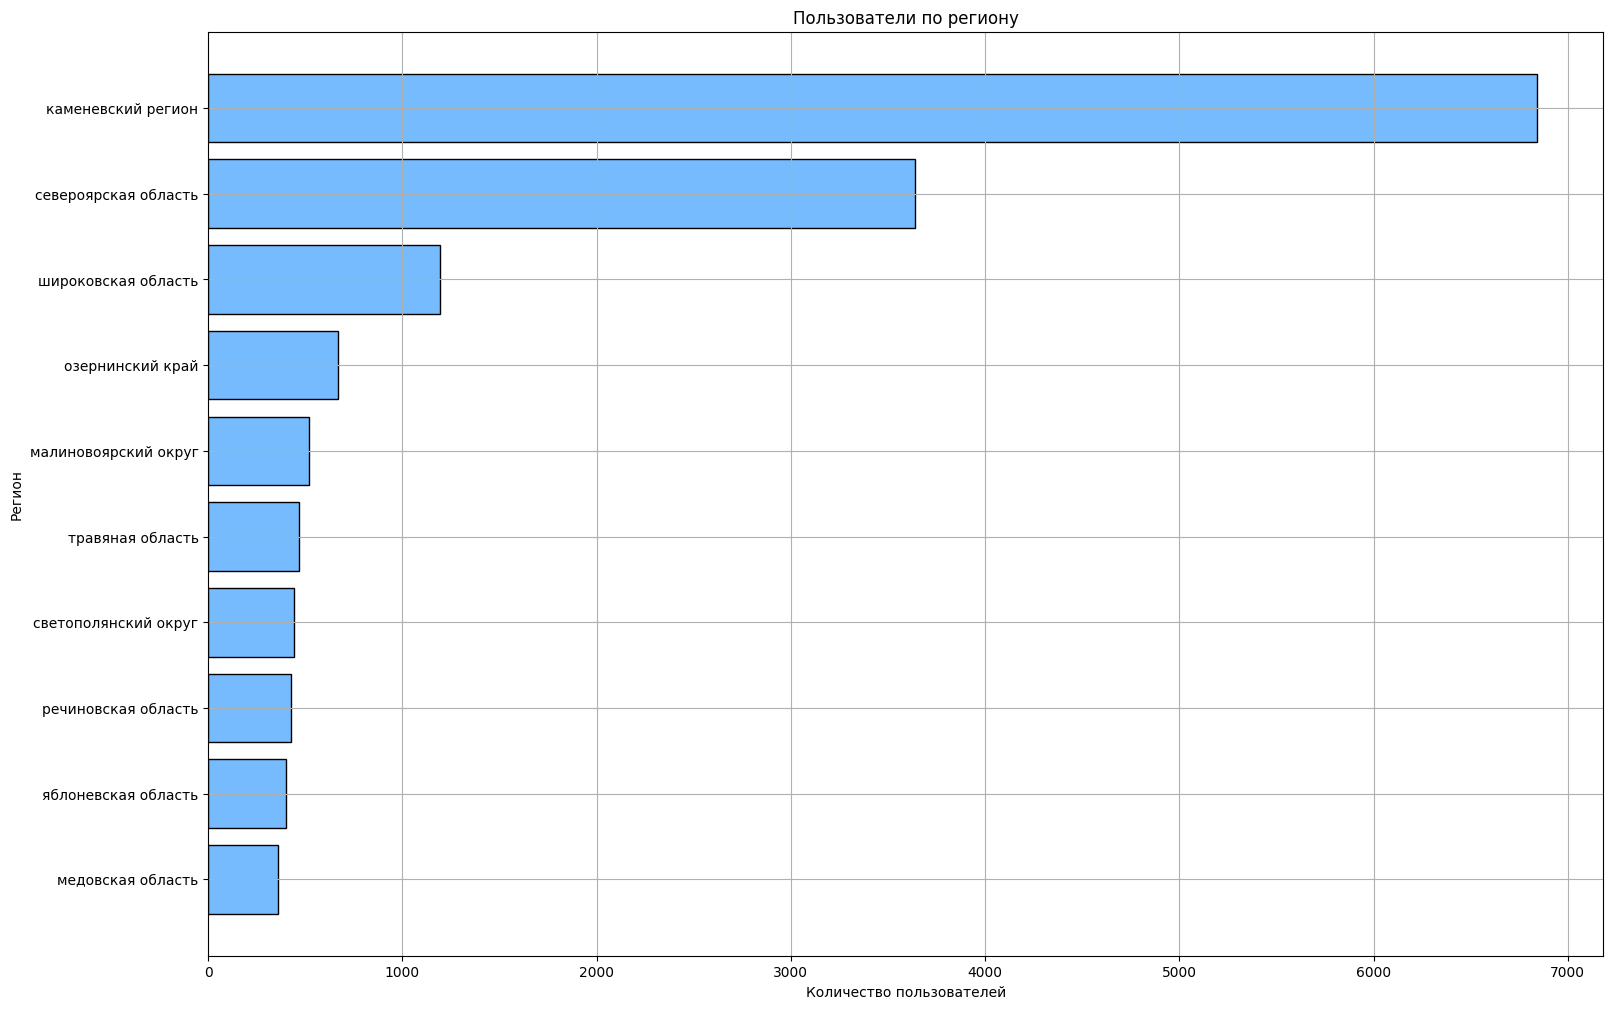

In [52]:
#Отберем в отдельном сегменте регионы у которых доля более 0.5%
seg_top_region = seg_region.head(10)
print(seg_top_region.head(100))
user_profile.show_diagramm(seg_top_region, title="Пользователи по региону",
                            Xcolumn='user_id',
                            YColumn='first_region',
                            xlabel="Количество пользователей", 
                            ylabel="Регион",
                            width=18,
                            height=12)

        firts_service_name  user_id      ratio
3       билеты без проблем     4997  24.274957
19             лови билет!     2732  13.271800
22               мой билет     2545  12.363371
4            билеты в руки     2448  11.892154
23                 облачко     2130  10.347340
7           весь в билетах     1242   6.033520
20           лучшие билеты     1139   5.533155
24               прачечная      558   2.710712
17            край билетов      441   2.142337
12            дом культуры      344   1.671120
33                  яблоко      308   1.496235
28             тебе билет!      301   1.462230
11  городской дом культуры      211   1.025018
21                мир касс      199   0.966723
13             за билетом!      197   0.957008
5              быстробилет      160   0.777265
1              show_ticket      158   0.767549
10          выступления.ру       93   0.451785
8                восьмёрка       83   0.403206
6           быстрый кассир       55   0.267185
0            

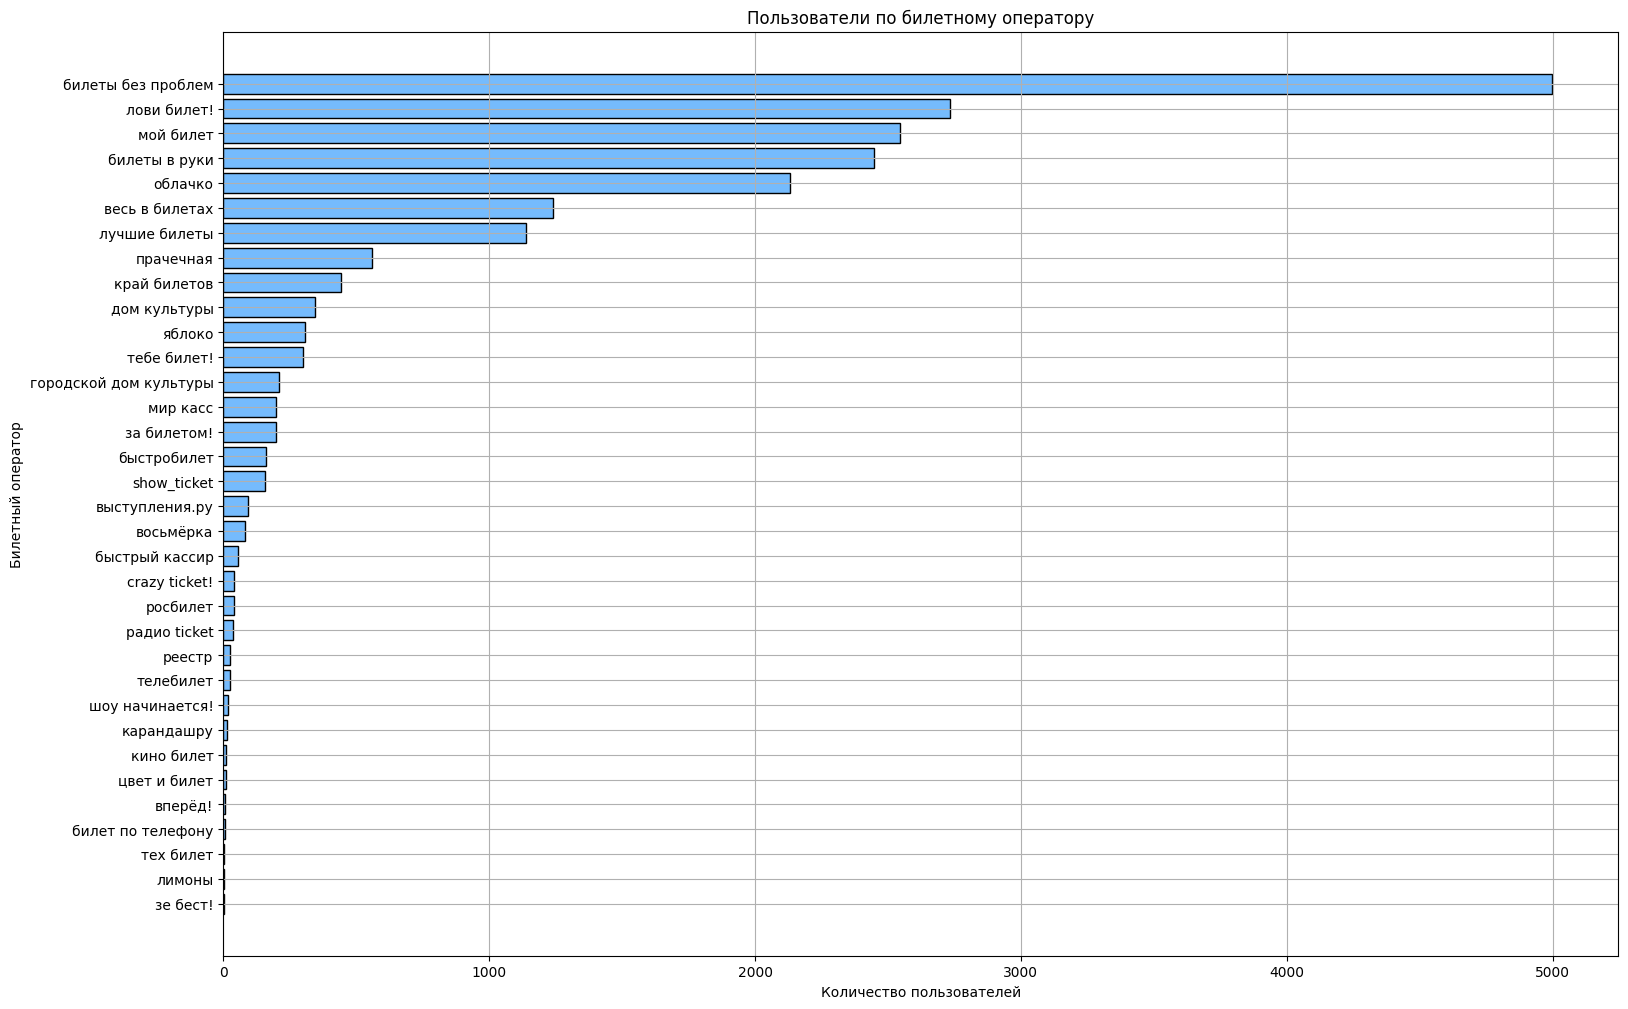

In [53]:
# Сгруппируем пользователей по билетному оператору
seg_service_name = user_profile.create_user_segment('firts_service_name', 'user_id')
print(seg_service_name.head(50))

user_profile.show_diagramm(seg_service_name, title="Пользователи по билетному оператору",
                            Xcolumn='user_id',
                            YColumn='firts_service_name',
                            xlabel="Количество пользователей", 
                            ylabel="Билетный оператор",
                            width=18,
                            height=12)

Выводы:
* Среди типов мероприятий выделяются концерты (~43%), другое (~26%) и театр (~20%)
* Наибольшая часть пользователей осуществляет заказы с помощью телефона (мобильного прилоложения) - 83%
* среди регионов выделяеься "каменевский регион" - примерно 33% всех пользоватлей, на втором месте "североярская область" ~18%, на третьем месте "широковская область" ~6%. В остальных регионах количество пользоватлей менее 3%
* Среди билетных операторов лидером является "билеты без проблем" - почти четверть всех заказов. Далее примерно одинаково около 12%: "лови билет!", "мой билет", "билеты в руки" и "облачко" 

Таким образом, пользователи распределены неравномерно, существуют выраженные «точки входа»:
- мероприятие - "концерт"
- устройство - "мобильный телефон"
- регион - "каменевский"
- оператор - "билеты без проблем"

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


  first_event_type  is_two      ratio
2         концерты    5322  43.310547
1           другое    3042  24.755859
5            театр    2549  20.743815
4          стендап     647   5.265299
3            спорт     420   3.417969
0         выставки     256   2.083333
6             ёлки      52   0.423177


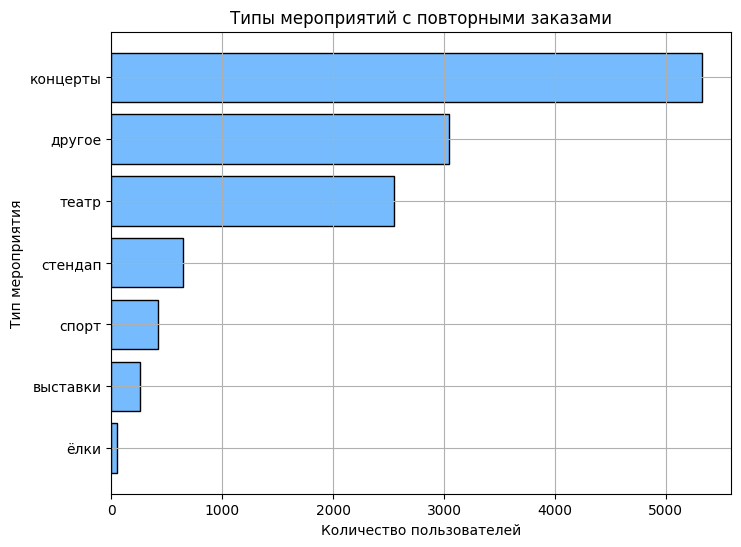

In [54]:
seg_event_type_repeat = user_profile.create_user_segment('first_event_type', 'is_two', group_agg='sum')
print(seg_event_type_repeat.head(10))

user_profile.show_diagramm(seg_event_type_repeat, title="Типы мероприятий с повторными заказами",
                            Xcolumn='is_two',
                            YColumn='first_event_type',
                            xlabel="Количество пользователей", 
                            ylabel="Тип мероприятия")

  first_device_type  is_two      ratio
1            mobile   10144  82.552083
0           desktop    2144  17.447917


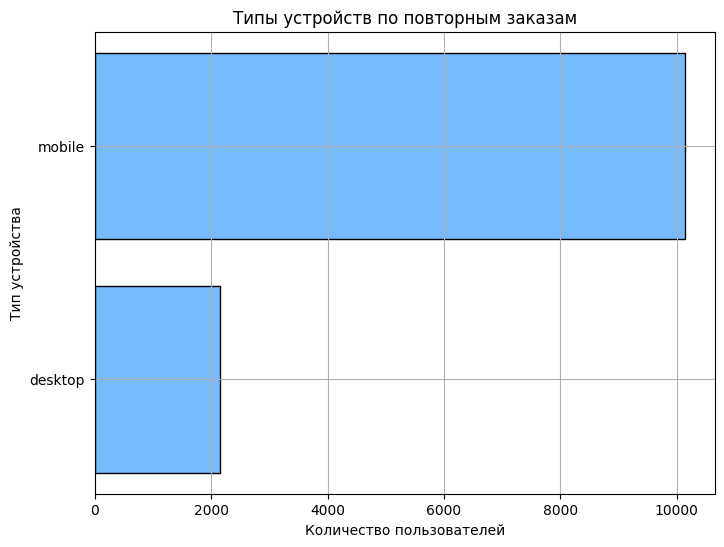

In [55]:
#Повторные заказы по типу усройства
seg_device_type_repeat = user_profile.create_user_segment('first_device_type', 'is_two', group_agg='sum')
print(seg_device_type_repeat.head(10))

user_profile.show_diagramm(seg_device_type_repeat, title="Типы устройств по повторным заказам",
                            Xcolumn='is_two',
                            YColumn='first_device_type',
                            xlabel="Количество пользователей", 
                            ylabel="Тип устройства")

In [56]:
#Повторные заказы по регионам
seg_region_repeat = user_profile.create_user_segment('first_region', 'is_two', group_agg='sum')
print(len(seg_region_repeat))

81


            first_region  is_two      ratio
23    каменевский регион    4169  33.927409
60  североярская область    2268  18.457031
77   широковская область     758   6.168620
45      озернинский край     363   2.954102
41  малиновоярский округ     289   2.351888
57  светополянский округ     286   2.327474
74      травяная область     281   2.286784
52   речиновская область     266   2.164714
78   яблоневская область     233   1.896159
42     медовская область     207   1.684570


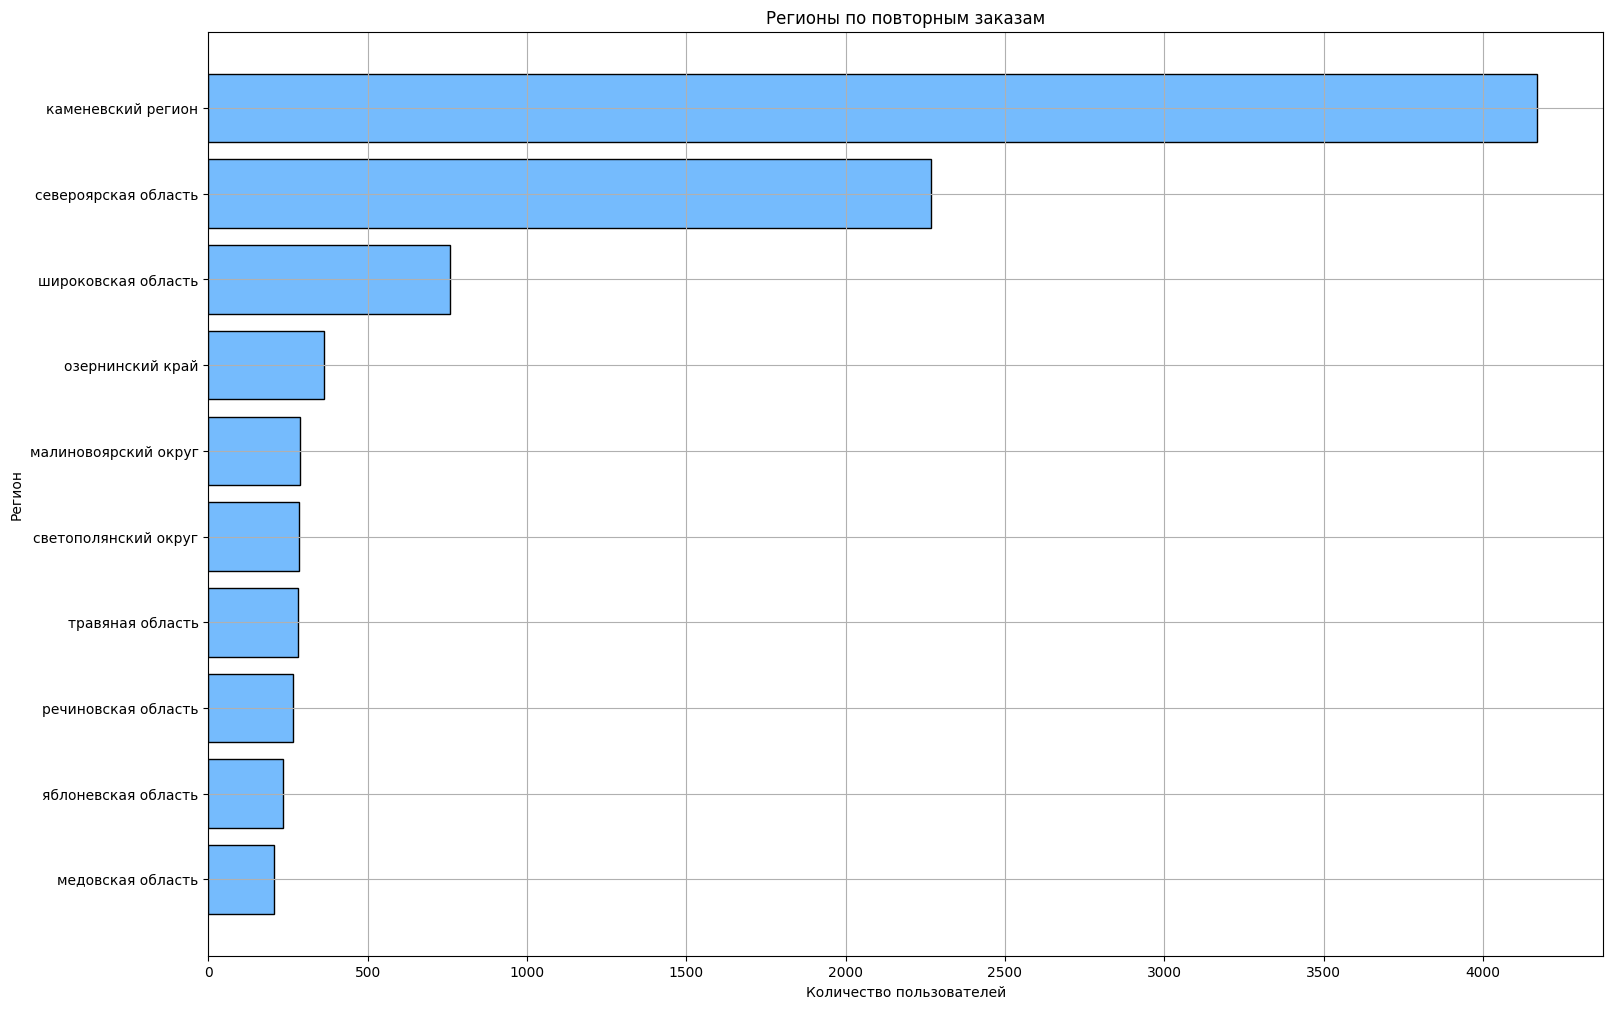

In [57]:
#Ограничимся 10 регионами с наибольшей долей повторных заказов
seg_top_region_repeat = seg_region_repeat.head(10)
print(seg_top_region_repeat.head(100))
user_profile.show_diagramm(seg_top_region_repeat, title="Регионы по повторным заказам",
                            Xcolumn='is_two',
                            YColumn='first_region',
                            xlabel="Количество пользователей", 
                            ylabel="Регион",
                            width=18,
                            height=12)

In [58]:
#Повторные заказы по билетным операторам
seg_service_name_repeat = user_profile.create_user_segment('firts_service_name', 'is_two', group_agg='sum')
print(len(seg_service_name_repeat))

34


    firts_service_name  is_two      ratio
3   билеты без проблем    2946  23.974609
19         лови билет!    1631  13.273112
4        билеты в руки    1494  12.158203
22           мой билет    1460  11.881510
23             облачко    1286  10.465495
7       весь в билетах     763   6.209310
20       лучшие билеты     678   5.517578
24           прачечная     339   2.758789
17        край билетов     283   2.303060
12        дом культуры     218   1.774089


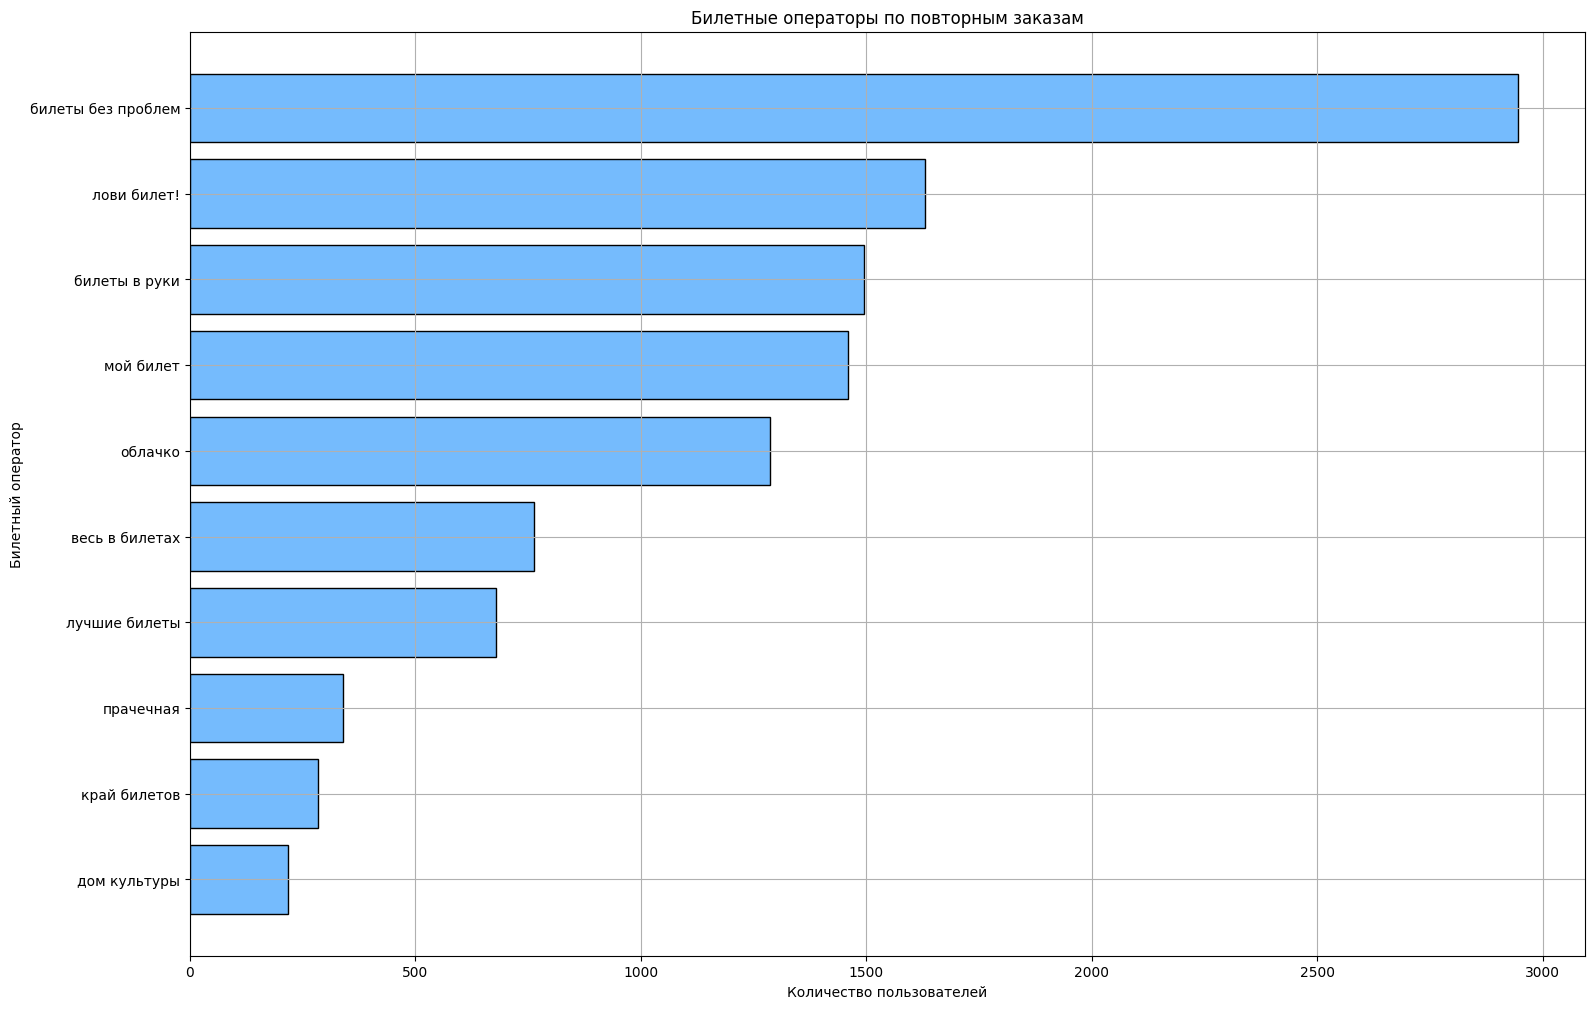

In [59]:
#Ограничимся 10 билетными операторами с наибольшей долей повторных заказов
seg_top_service_name_repeat = seg_service_name_repeat.head(10)
print(seg_top_service_name_repeat.head(100))
user_profile.show_diagramm(seg_top_service_name_repeat, title="Билетные операторы по повторным заказам",
                            Xcolumn='is_two',
                            YColumn='firts_service_name',
                            xlabel="Количество пользователей", 
                            ylabel="Билетный оператор",
                            width=18,
                            height=12)

Выводы:
* Среди типов мероприятий по повторным заказам выделяются концерты (~43%), другое (~25%) и театр (~21%) - такие же мероприятия и в такой же доле были отмечены как наиболее востребоваными
* Наибольшая часть пользователей осуществляет повторыне заказы с помощью телефона (мобильного прилоложения) - 83% - аналогично доле всех совершенных заказов
* среди регионов выделяеься "каменевский регион" - примерно 34% всех пользоватлей, на втором месте "североярская область" ~18%, на третьем месте "широковская область" ~6%. В остальных регионах количество пользоватлей менее 3%. Аналогично анализу всех регионов.
* Среди билетных операторов лидером является "билеты без проблем" - почти четверть всех заказов. Далее примерно одинаково около 12%: "лови билет!", "мой билет", "билеты в руки", "мой билет" и "облачко" 

Таким образом, повторные заказы осуществляются на те же мероприятия, в том же регионе, с того же устройства и у того же билетного оператора, что и все заказы 
Пользователи распределены неравномерно, сохраняются выраженные «точки входа»:
- мероприятие - "концерт"
- устройство - "мобильный телефон"
- регион - "каменевский"
- оператор - "билеты без проблем"

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [60]:
# Проверка гипотезы 1
#seg_event_type - сегмент по типам мероприятий
#seg_event_type_repeat - сегмент по повторным заказам по типам мероприятий

# Объединяем сегменты по типу события
merged_event_type = pd.merge(seg_event_type[['first_event_type', 'user_id']],
                  seg_event_type_repeat[['first_event_type', 'is_two']],
                  on='first_event_type')

# Вычисляем долю
merged_event_type['share'] = (merged_event_type['is_two'] / merged_event_type['user_id']) * 100

# Выводим для нужных типов
for event in ['спорт', 'концерты']:
    share = merged_event_type.loc[merged_event_type['first_event_type'] == event, 'share'].values[0]
    print(f"{event}: {share:.2f}%")

спорт: 54.19%
концерты: 60.05%


Вывод: гипотеза № 1 не подтверждается, пользователи, которые сделали перввый раз заказ на концерты чаще делают второй заказ, в отличие от пользователей, которые сделали первый заказ на спортивное мероприятие.

In [61]:
# Проверка гипотезы 2
#seg_top_region - сегмент топ 10 регионов по количеству заказов
#seg_top_region_repeat - сегмент топ 10 по повторным заказам по регионам

# Объединяем сегменты по типу события
merged_region = pd.merge(seg_top_region[['first_region', 'user_id']],
                  seg_top_region_repeat[['first_region', 'is_two']],
                  on='first_region')

# Вычисляем долю
merged_region['share'] = (merged_region['is_two'] / merged_region['user_id']) * 100
merged_region.head(10).sort_values('share', ascending=False)


,first_region,user_id,is_two,share
6,светополянский округ,443,286,64.559819
2,широковская область,1193,758,63.537301
1,североярская область,3637,2268,62.359087
7,речиновская область,427,266,62.295082
0,каменевский регион,6841,4169,60.941383
5,травяная область,469,281,59.914712
8,яблоневская область,400,233,58.250000
9,медовская область,359,207,57.660167
4,малиновоярский округ,521,289,55.470250
3,озернинский край,666,363,54.504505


Вывод: гипотеза № 2 не подтверждается. Наибольшее количество заказов в каменевском районе, однако доля повторных заказов ~61%, в то время как светополянский округ лидирует по доле повторных заказов (~65%) при 443 заказах (7 место в топ регионов) 

---
<a id="section42"></a>
#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


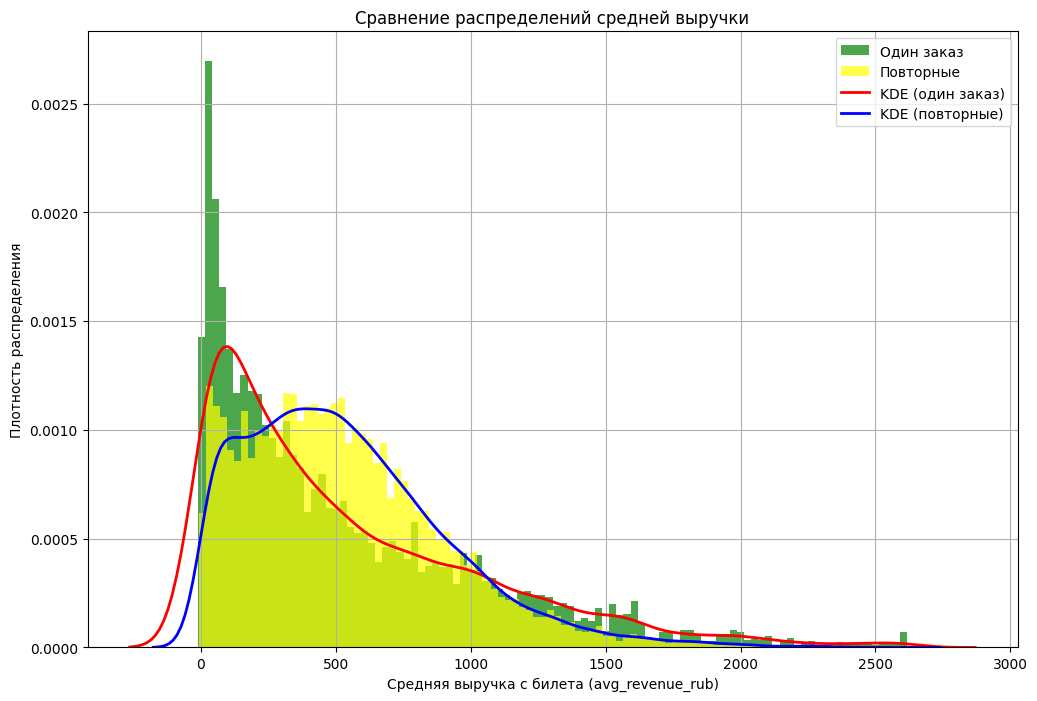

In [62]:
#Выделилим отдельно датафреймы с одним заказом и более однго
one_order = df_analisys[df_analisys['qty_orders'] == 1].copy()
multiple_orders = df_analisys[df_analisys['qty_orders'] >= 2].copy()

# Построение гистограмм
plt.figure(figsize=(12, 8))
plt.hist(one_order['avg_revenue_rub'], bins=100, alpha=0.7, density=True,
         label='Один заказ', color='green')
plt.hist(multiple_orders['avg_revenue_rub'], bins=100, alpha=0.7, density=True,
         label='Повторные', color='yellow')

# Добавляем KDE (сглаженные кривые плотности)
sns.kdeplot(one_order['avg_revenue_rub'], color='red', linewidth=2, label='KDE (один заказ)')
sns.kdeplot(multiple_orders['avg_revenue_rub'], color='blue', linewidth=2, label='KDE (повторные)')

plt.xlabel('Средняя выручка с билета (avg_revenue_rub)')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределений средней выручки')
plt.legend()
plt.grid(True)
plt.show()

Выводы:
* Пользователи с одним заказом в основном концентрируются от 100 до 500 рублей средней выручки
* Пользователи с двумя и более заказов - от 100 до 1000
* Пользователи с повторными заказами принсосят больше выручки, то есть пользователи тратят больше, чем при первом заказе

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


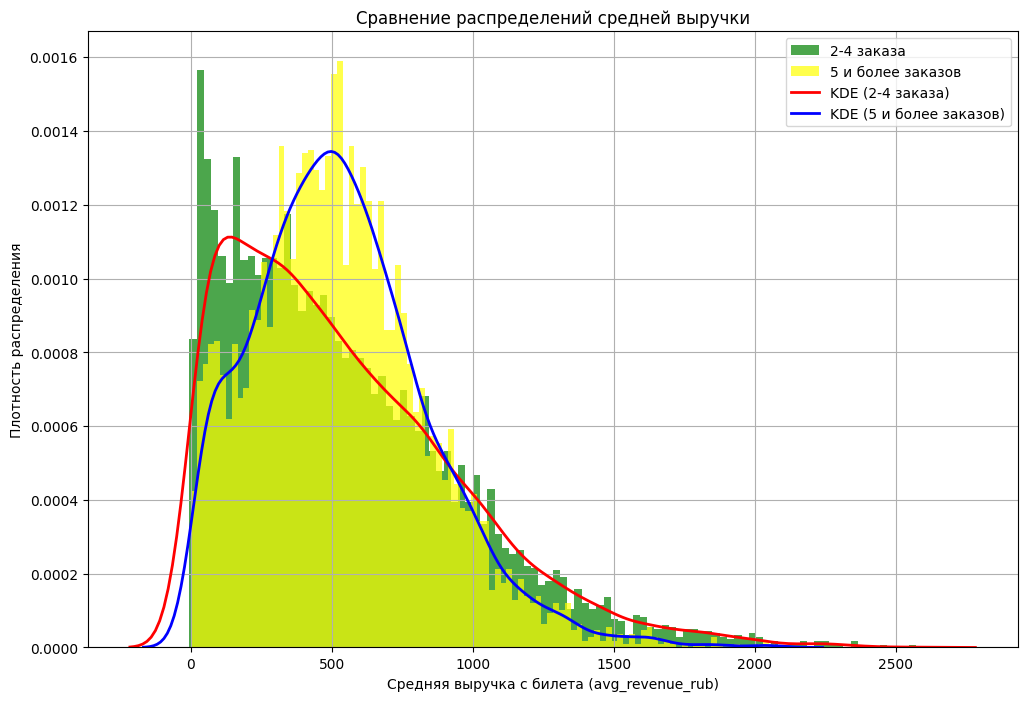

In [63]:
#Выделилим отдельно датафреймы с 2-4 закза и более однго
two_four_order = df_analisys[(df_analisys['qty_orders'] >= 2) & (df_analisys['qty_orders'] <= 4)].copy()
five_orders = df_analisys[df_analisys['is_five'] == True].copy()

# Построение гистограмм
plt.figure(figsize=(12, 8))
plt.hist(two_four_order['avg_revenue_rub'], bins=100, alpha=0.7, density=True,
         label='2-4 заказа', color='green')
plt.hist(five_orders['avg_revenue_rub'], bins=100, alpha=0.7, density=True,
         label='5 и более заказов', color='yellow')

# Добавляем KDE (сглаженные кривые плотности)
sns.kdeplot(two_four_order['avg_revenue_rub'], color='red', linewidth=2, label='KDE (2-4 заказа)')
sns.kdeplot(five_orders['avg_revenue_rub'], color='blue', linewidth=2, label='KDE (5 и более заказов)')

plt.xlabel('Средняя выручка с билета (avg_revenue_rub)')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределений средней выручки')
plt.legend()
plt.grid(True)
plt.show()

Вывод: пользователи, совершившие 5 и более заказов приносят выручки больше. Пик приходится на 500 рублей средней выручки с билета. Пользователи от 2-4 заказов принсят меньше средней выручки, пик приходится примерно на 200 рублей выручки с билета.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

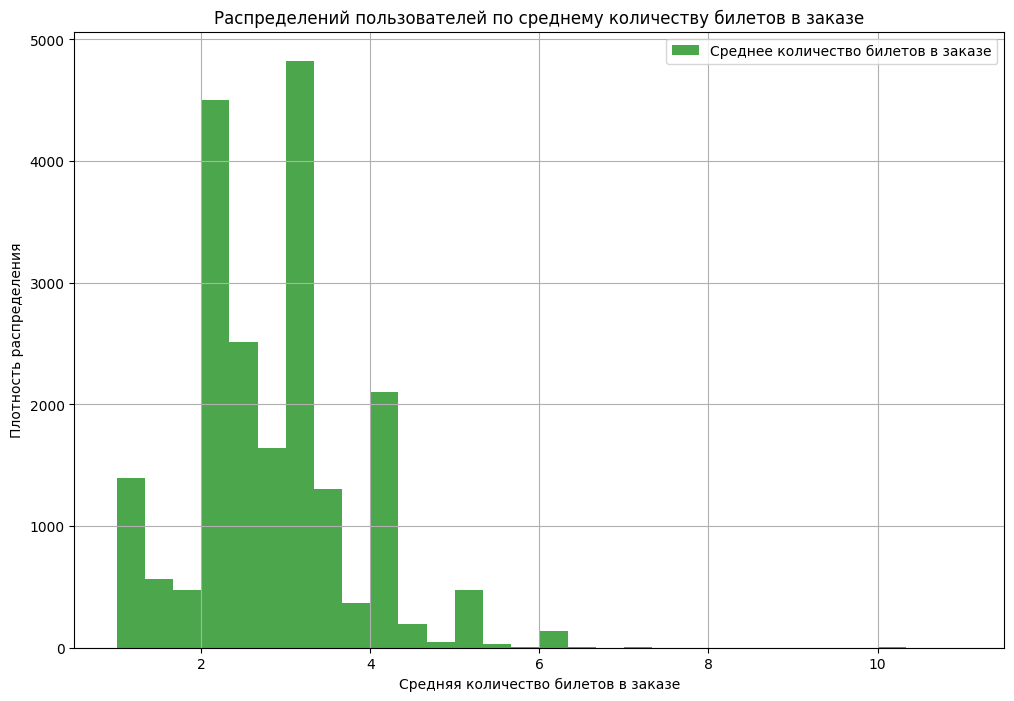

In [64]:
#Выделилим отдельно датафрейм для анализа билетов
tickets = df_analisys[df_analisys['avg_tickets'].notna()].copy()

# Построение гистограммы
plt.figure(figsize=(12, 8))
plt.hist(tickets['avg_tickets'], bins=30, alpha=0.7, label='Среднее количество билетов в заказе', color='green')
plt.xlabel('Средняя количество билетов в заказе')
plt.ylabel('Плотность распределения')
plt.title('Распределений пользователей по среднему количеству билетов в заказе')
plt.legend()
plt.grid(True)
plt.show()

Вывод: Распределений пользователей по среднему количеству билетов в заказе показывает, что наиболее часто пользователи заказывают 3 билета, чуть реже - 2. Так же стоит отметить, что нередко заказывают 4 билета или 1. Это говорит о том, что пользователи видимо предпочитают ходить на мероприятие группой, чаще втроем или вдвоем.

In [65]:
tickets_analisys = df_analisys.copy()

# Функция, которая по числу билетов возвращает имя группы
def get_group(x):
    if x < 2:
        return '1-2 билета'
    elif x < 3:
        return '2-3 билета'
    elif x < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

tickets_analisys['group'] = tickets_analisys['avg_tickets'].apply(get_group)

result = tickets_analisys.groupby('group').agg(
    всего_пользователей=('user_id', 'count'),
    повторные=('is_two', 'sum')
)
result['доля_повторных_%'] = (result['повторные'] / result['всего_пользователей'] * 100).round(1)

print(result)


             всего_пользователей  повторные  доля_повторных_%
group                                                        
1-2 билета                  2435       1235              50.7
2-3 билета                  8657       6180              71.4
3-5 билетов                 8833       4749              53.8
5+ билетов                   660        124              18.8


Вывод:
* Пользователи распределены по сегментам сконцентрировано.Больше всего людей в двух группах: 2–3 билета (8657 человек) и 3–5 билетов (8833 человека). Вместе они составляют почти 85% всех пользователей. Группа 1–2 билета заметно меньше (2435), а группа 5+ билетов совсем маленькая (660).То есть основная масса людей покупает в среднем от 2 до 5 билетов за заказ. Равномерного распределения нет.
* Аномально высокая доля — в группе 2–3 билета (71.4%). Почти три из четырёх таких пользователей возвращаются за новыми покупками.
Аномально низкая доля — в группе 5+ билетов (всего 18.8%). Те, кто покупает много билетов за раз почти не возвращаются.
Группа 3–5 билетов (53.8%) и 1–2 билета (50.7%) — примерно половина покупает ещё раз.

---
<a id="section43"></a>
#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


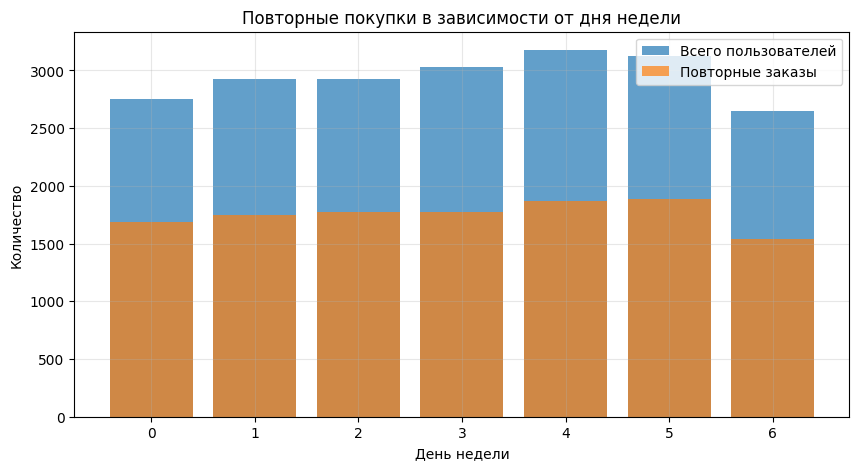

   weekday_num  total_users  repeats  repeat_rate
0            0         2757     1691    61.334784
1            1         2927     1747    59.685685
2            2         2928     1778    60.724044
3            3         3028     1778    58.718626
4            4         3177     1869    58.829084
5            5         3122     1887    60.442024
6            6         2646     1538    58.125472


In [66]:
days_analisys = df_analisys.copy()
days_analisys['first_order_dt'] = pd.to_datetime(days_analisys['first_order_dt'])

# Получаем номер дня недели (0 = понедельник, 6 = воскресенье)
days_analisys['weekday_num'] = days_analisys['first_order_dt'].dt.dayofweek

days_stats = days_analisys.groupby('weekday_num').agg(
    total_users=('user_id', 'count'),
    repeats=('is_two', 'sum')   
).reset_index()

days_stats['repeat_rate'] = days_stats['repeats'] / days_stats['total_users']*100
plt.figure(figsize=(10, 5))
plt.bar(days_stats['weekday_num'], days_stats['total_users'], label='Всего пользователей', alpha=0.7)
plt.bar(days_stats['weekday_num'], days_stats['repeats'], label='Повторные заказы', alpha=0.7)
plt.xlabel('День недели')
plt.ylabel('Количество')
plt.title('Повторные покупки в зависимости от дня недели')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Печатаем табличку
print(days_stats)

Выводы:
Максимальная доля возврата – в понедельник (61,33%)
Минимальная доля – в воскресенье (58,13%)
Разница – около 3,2 процентных пункта
При таком большом количестве наблюдений (от 2600 до 3200 пользователей в день) разница в 3% является значимой. Это означает, что наблюдаемые различия не случайны.

Клиенты, которые совершили первую покупку в понедельник, возвращаются немного чаще.
Клиенты с первой покупкой в воскресенье возвращаются реже.
Однако в целом разница небольшая – день недели не является главным фактором возврата, но влияет на него.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [67]:
order_days_analisys = df_analisys.copy()

# Средний интервал для группы 2-4 заказа (is_two True, is_five False)
order_days_analisys_two = order_days_analisys[(order_days_analisys['is_two'] == True) & (order_days_analisys['is_five'] == False)]['avg_order_days'].mean()

# Средний интервал для группы 5+ заказов (is_five True)
order_days_analisys_five = order_days_analisys[order_days_analisys['is_five'] == True]['avg_order_days'].mean()

print("2-4 заказа:", order_days_analisys_two)
print("5 и более заказов:", order_days_analisys_five)

2-4 заказа: 21.3968180960468
5 и более заказов: 11.091743859102385


Выводы:
* Пользователи, которые дошли до 5+ заказов, заказывают в 2 раза чаще (11 дней против 21 дня).

---
<a id="section44"></a>
#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [82]:
#Ранее профиль пользователя строили по параметрам: тип устройства, тип мероприятия, регион и билетный оператор. Будем искать корреляцию по количеству заказов среди именно этих параметров.
cols = ['qty_orders', 'first_device_type', 'first_region', 'firts_service_name', 'first_event_type']

corr_subset = df_analisys[cols].copy()
phi_matrix_all = corr_subset.phik_matrix(interval_cols=['qty_orders'])

# Извлекаем корреляции с qty_orders (исключаем саму строку qty_orders)
corr_with_orders_all = phi_matrix_all.loc[phi_matrix_all.index != 'qty_orders', 'qty_orders'].sort_values(ascending=False)
print("Корреляция phi_k между признаками профиля и qty_orders (все данные)")
print(corr_with_orders_all)



Корреляция phi_k между признаками профиля и qty_orders (все данные)
firts_service_name    0.052108
first_event_type      0.033097
first_device_type     0.023783
first_region          0.000000
Name: qty_orders, dtype: float64


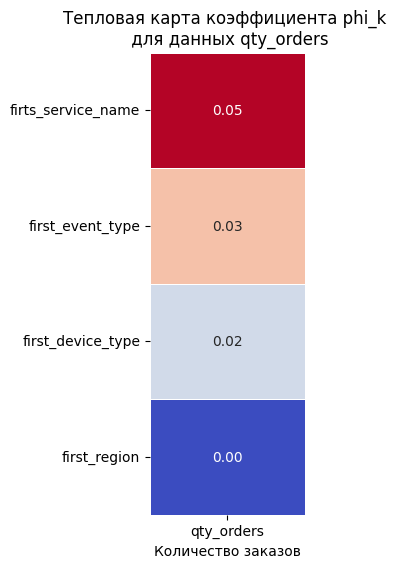

In [83]:
plt.figure(figsize=(2, 6))

# Берём столбец 'qty_orders', удаляем из него строку 'qty_orders' и сортируем
data_heatmap = phi_matrix_all['qty_orders'].drop('qty_orders').sort_values(ascending=False)

# Преобразуем Series в DataFrame (формат (n,1)) для sns.heatmap
sns.heatmap(data_heatmap.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False)

plt.title('Тепловая карта коэффициента phi_k \n для данных qty_orders')
plt.xlabel('Количество заказов')
plt.show()

In [84]:
#Распределение количества заказов
print(corr_subset['qty_orders'].value_counts().sort_index())

qty_orders
1     8297
2     3542
3     2148
4     1376
5      968
6      699
7      530
8      447
9      381
10     293
11     227
12     199
13     148
14     149
15     121
16     135
17     110
18      91
19      67
20      64
21      76
22      67
23      57
24      72
25      55
26      48
27      51
28      46
29      38
30      25
31      30
32      28
Name: count, dtype: int64


In [85]:
def segment_orders(x):
    if x == 1:
        return '1 заказ'
    elif 2 <= x <= 4:
        return '2-4 заказа'
    else:  # x >= 5
        return '5+ заказов'

corr_subset['segment'] = corr_subset['qty_orders'].apply(segment_orders)

# Проверим размеры сегментов
print("Размеры сегментов:")
print(corr_subset['segment'].value_counts())

Размеры сегментов:
segment
1 заказ       8297
2-4 заказа    7066
5+ заказов    5222
Name: count, dtype: int64


Сегмент '1 заказ' имеет постоянное значение qty_orders = 1, пропускаем.

=== Корреляция phi_k в сегменте '2-4 заказа' ===
firts_service_name    0.078023
first_device_type     0.004935
first_region          0.000000
first_event_type      0.000000
Name: qty_orders, dtype: float64

=== Корреляция phi_k в сегменте '5+ заказов' ===
first_event_type      0.068411
firts_service_name    0.022591
first_device_type     0.009432
first_region          0.000000
Name: qty_orders, dtype: float64


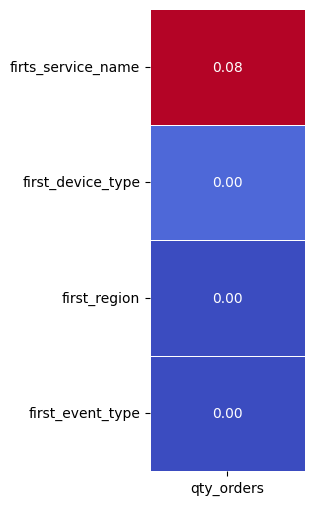

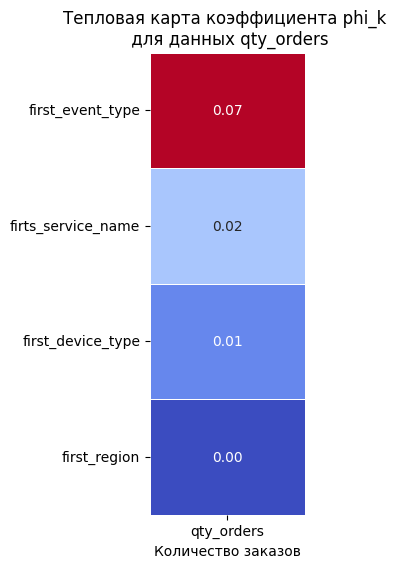

In [86]:
segments = ['1 заказ', '2-4 заказа', '5+ заказов']
results = {}

for seg in segments:
    df_seg = corr_subset[corr_subset['segment'] == seg].copy()
    
    # Проверка: если в сегменте все значения qty_orders одинаковы, корреляция не имеет смысла
    if df_seg['qty_orders'].nunique() < 2:
        print(f"Сегмент '{seg}' имеет постоянное значение qty_orders = {df_seg['qty_orders'].iloc[0]}, пропускаем.")
        continue
    
    if len(df_seg) < 5:  # минимальное количество наблюдений для устойчивости
        print(f"Сегмент '{seg}' слишком мал (n={len(df_seg)}), пропускаем.")
        continue
    
    df_seg_subset = df_seg[cols].copy()
    phi_matrix_seg = df_seg_subset.phik_matrix(interval_cols=['qty_orders'])
   
   
    corr_with_orders_seg = phi_matrix_seg.loc[phi_matrix_seg.index != 'qty_orders', 'qty_orders'].sort_values(ascending=False)
    results[seg] = corr_with_orders_seg
    print(f"\n=== Корреляция phi_k в сегменте '{seg}' ===")
    print(corr_with_orders_seg)

    plt.figure(figsize=(2, 6))

    data_heatmap = phi_matrix_seg['qty_orders'].drop('qty_orders').sort_values(ascending=False)

    sns.heatmap(data_heatmap.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False)

plt.title('Тепловая карта коэффициента phi_k \n для данных qty_orders')
plt.xlabel('Количество заказов')
plt.show()


Вывод:
* анализ показал, что с числом покупок очень слабо связаны параметры профиля пользователя.
* пользователи покупают такое количество билетов по како-то другой причине, вне зависимости от того с какого устройства делается заказ, на какое мероприятие они собираются идти, у какого оператора покупают и в каком регионе.

<a id="section5"></a>
### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Общие выводы:

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**